In [12]:
""" Codigo simulaciones Ganvito N.
rand_mwb1_110 """




import healpy as hp

import numpy as np

import math as m

import pandas as pd

import astropy
import astropy.units as u
import astropy.coordinates as coord

import statistics


import matplotlib.pyplot as plt

print('Versión de Pandas es: ', np.__version__)
print('La versión de Numpy es: ', pd.__version__)
print('La versión de healpy es: ', pd.__version__)

Versión de Pandas es:  1.26.4
La versión de Numpy es:  2.2.2
La versión de healpy es:  2.2.2


In [13]:
#lectura de datos

mc = pd.read_csv('rand_mwlmc5b0_110.txt', sep=' ',
                  names=['x','y','z','vx', 'vy', 'vz'])

#mc = pd.read_csv('/content/drive/MyDrive/rand_mwb1_110.txt', sep=' ',
                  #names=['x','y','z','vx', 'vy', 'vz'])
#pd.DataFrame(mc)

# con x,y,z en kpc y vx, vy, vz en km/s

# Cálculo de las coordenadas esféricas $r, \theta, \phi$ con ```astropy```

In [14]:
from astropy.coordinates import cartesian_to_spherical

x = mc['x'].values #* u.Mpc
y = mc['y'].values #* u.Mpc
z = mc['z'].values #* u.Mpc

#
spherical_coords = cartesian_to_spherical(x, y, z)

#
r = spherical_coords[0]#.to(u.Mpc, equivalencies=u.dimensionless_angles()).value
theta = spherical_coords[1].to(u.rad).value
phi = spherical_coords[2].to(u.rad).value
phi2 = spherical_coords[2].to(u.degree).value

# Añadir los resultados de nuevo al DataFrame
mc['R'] = r
mc['theta'] = theta
mc['phi'] = phi
mc['phi2'] = phi2  # en grados
mc['cotheta'] = np.pi/2 - theta

mc

,x,y,z,vx,vy,vz,R,theta,phi,phi2,cotheta
0,-9.073973,134.529449,52.583729,-162.274078,-29.927361,96.407394,144.725804,0.371843,1.638144,93.858739,1.198953
1,-28.404976,53.197102,-136.105240,-43.992241,-72.750572,230.643051,148.867090,-1.153711,2.061239,118.100309,2.724507
2,5.671879,-50.859417,-20.001068,-39.119331,72.849449,222.935043,54.944456,-0.372584,4.823451,276.363373,1.943380
3,-34.947304,-43.726669,-15.888982,-2.000596,-104.936783,241.940506,58.187588,-0.276577,4.038123,231.367392,1.847374
4,-48.037086,22.731808,-69.944145,164.281570,-77.371971,-42.808468,87.843498,-0.921048,2.699603,154.675846,2.491844
...,...,...,...,...,...,...,...,...,...,...,...
999995,-52.940460,1.057030,-0.767179,-26.956795,113.120132,-29.164295,52.956569,-0.014487,3.121629,178.856162,1.585284
999996,3.171290,35.912395,-35.208454,157.058807,103.576843,-51.752743,50.392385,-0.773559,1.482719,84.953513,2.344356
999997,11.692700,5.368427,64.118584,-206.644135,10.167513,-39.430645,65.396728,1.372764,0.430417,24.661104,0.198033
999998,-79.273514,155.210205,-20.541859,14.234056,127.901489,-28.539112,175.489218,-0.117324,2.043006,117.055644,1.688120


In [15]:
l = coord.Angle(((mc['phi']*180)/np.pi), unit=u.deg)
ll = l.wrap_at(180*u.degree)
mc['phi2']=ll.value

In [16]:
print("Minimo y maximo de R: ", mc['R'].min(), mc['R'].max())
print("Minimo y maximo de theta: ",mc['theta'].min(), mc['theta'].max())
print("Minimo y maximo de phi: ",mc['phi'].min(), mc['phi'].max())
print("Minimo y maximo de phi2: ",mc['phi2'].min(), mc['phi2'].max())

print("Promedio de R: ", np.mean(mc['R']))
print("Promedio de theta: ", np.mean(mc['theta']))
print("Promedio de phi: ", np.mean(mc['phi']))
print("Promedio de phi: ", np.mean(mc['phi2']))

Minimo y maximo de R:  50.00006467750145 499.99957211280224
Minimo y maximo de theta:  -1.568702387280011 1.5674532971751243
Minimo y maximo de phi:  5.850232583308473e-07 6.283184329953387
Minimo y maximo de phi2:  -179.99995101172323 179.99911499960766
Promedio de R:  163.54176326281603
Promedio de theta:  0.07236412346288092
Promedio de phi:  3.221834345257562
Promedio de phi:  -5.477809726446737


# Calculo de las velocidades radiales, polares y azimutales

In [17]:
# con el vector velocidad en coordenadas cartesianas: v = vx i^  + vy j^  + vz k^
# y con los versores e_r^ e_theta^ e_phi^ (radial, polar, azimutal)

mc['vr2'] = np.sin(mc['cotheta']) * np.cos(mc['phi'])* mc['vx'] + np.sin(mc['cotheta']) * np.sin(mc['phi']) * mc['vy'] + np.cos(mc['cotheta']) * mc['vz']

mc['vtheta2'] = np.cos(mc['cotheta'])* np.cos(mc['phi']) * mc['vx'] + np.sin(mc['phi']) * np.cos(mc['cotheta']) * mc['vy'] - np.sin(mc['cotheta']) * mc['vz']

mc['vphi2'] =  (- np.sin(mc['phi'])) * mc['vx'] +  np.cos(mc['phi']) * mc['vy']

# Función ```cat_to_hpx(lon, lan, nside, radec=True)```

In [18]:
from astropy.coordinates import SkyCoord

def cat_to_hpx(lon, lat, nside, radec=False):   #radec=False: si vamos de cartesianas a esfericas galacticas
    """
    Convierte un catálogo a un mapa HEALPix de densidad de número, es decir,
    el número de estrellas por grado cuadrado de cielo.

    Parámetros
    ----------
    lon, lat : (arreglo, arreglo)
        Coordenadas de las fuentes en grados.
        Si radec=True, asume que la entrada está en el sistema ICRS,
        De lo contrario, asume que la entrada está en latitud y longitud galáctica.

    nside : int
        Número HEALPix nside del mapa de destino, define el número de píxeles.

    radec : bool
        Cambio entre Ra/Dec y l/b (galáctico) como sistema de coordenadas de entrada.

    Return
    ------
    hpx_map : arreglo
        Mapa HEALPix de los recuentos de número del catálogo en coordenadas galácticas
    """
    npix = hp.nside2npix(nside)

    if radec:
        eq = SkyCoord(lon, lat, unit='deg')
        l, b = eq.galactic.l.value, eq.galactic.b.value
    else:
        l, b = lon, lat

    #b = latitud  l = longitud

    # convertir a theta, phi -> longitud galáctica y colatitud en el sistema esférico
    theta = np.radians(90. - b)
    phi = np.radians(l)


    # convertir a índices HEALPix
    #indices = hp.ang2pix(nside, l,b, lonlat=True)    # en grados
    indices = hp.ang2pix(nside, l,b, lonlat=False)   # en radianes  OJO


    indx, counts = np.unique(indices, return_counts=True)

    # llenar el mapa de cielo completo
    hpx_map = np.zeros(npix, dtype=int)
    hpx_map[indx] = counts

    return hpx_map


## Condición para una shell de 5 kpc de espesor centrada en un radio de 50kpc
(52.5 kpc)

In [19]:
# condicion para filtrar estrellas en 50 kpc

radio_interno_shell = 50.0      #kpc
radio_externo_shell = 55.0      #kpc

estrellas_shell = mc[(mc['R'] >= radio_interno_shell)  & (mc['R'] <= radio_externo_shell)]

estrellas_shell

,x,y,z,vx,vy,vz,R,theta,phi,phi2,cotheta,vr2,vtheta2,vphi2
2,5.671879,-50.859417,-20.001068,-39.119331,72.849449,222.935043,54.944456,-0.372584,4.823451,-83.636627,1.943380,-152.625037,-179.705594,-30.804147
40,-6.454873,-42.682911,-26.285553,119.622513,118.351654,257.198761,50.541335,-0.546945,4.562298,-98.599593,2.117741,-248.991303,-149.514918,100.580726
50,22.171886,-18.741781,-44.594841,-22.051144,-15.607617,-35.571812,53.212280,-0.993709,5.581429,-40.207664,2.564506,26.120256,25.076912,-26.155022
52,5.027425,-38.738457,37.786442,0.397110,81.752129,0.212936,54.348489,0.768784,4.841446,-82.605560,0.802012,-58.086413,-56.483975,10.915255
57,-21.378719,-39.851784,-26.285954,176.844971,-111.467995,55.205513,52.308371,-0.526510,4.220004,-118.211590,2.097306,-15.096057,-55.079022,208.531332
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999977,-36.996426,39.285053,4.023776,-190.582657,-249.204987,-89.886688,54.113230,0.074427,2.326201,133.281504,1.496369,-57.302770,85.863449,309.593850
999981,32.022293,22.319279,-37.947979,207.056839,3.515036,151.288773,54.439201,-0.771304,0.608704,34.876184,2.342100,17.777349,-228.284974,-115.512420
999990,-47.830002,2.018963,-17.294846,-106.299210,-309.568054,90.701355,50.900854,-0.346678,3.099406,177.582910,1.917474,56.789205,-116.954952,313.775657
999995,-52.940460,1.057030,-0.767179,-26.956795,113.120132,-29.164295,52.956569,-0.014487,3.121629,178.856162,1.585284,29.629009,28.738077,-112.559469


## Densidad con cat_to_pix y

Contraste de densidad 50 kpc


$$\Delta = \frac{\rho - \bar{\rho}}{\bar{\rho}}$$

In [20]:
# mapa de densidad

nside=8
#nside=16

#phi2 = estrellas_shell['phi2'].values     OJO theta = estrellas_shell['cotheta'] por ahora
phi = estrellas_shell['phi'].values
theta = estrellas_shell['cotheta'].values


mapa_hpx = cat_to_hpx(theta, phi,  nside, radec=False)      #lon = l, lat = b radianes


sobredensidad_cat = (mapa_hpx - np.mean(mapa_hpx))/(np.mean(mapa_hpx))

10.163293497790086
0.150940002442427


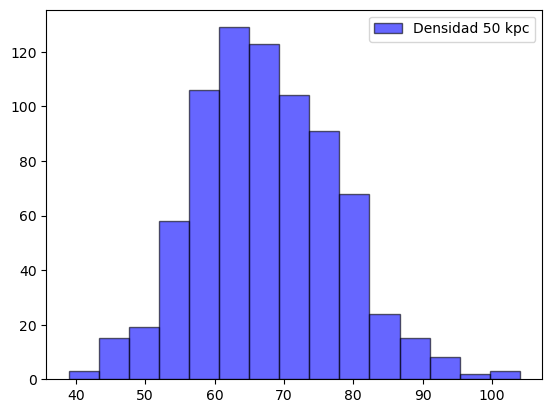

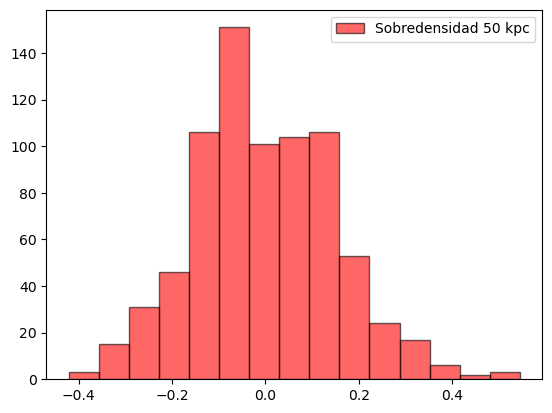

In [21]:

#dispersion densidad y sobre
dispersion_den = np.std(mapa_hpx)
dispersion_sobre = np.std(sobredensidad_cat)
print(dispersion_den)
print(dispersion_sobre)

plt.hist(mapa_hpx, bins=15, color='blue',alpha= 0.6, edgecolor='black', label='Densidad 50 kpc')
plt.legend()
plt.show()
plt.hist(sobredensidad_cat, bins=15, color='red',alpha= 0.6, edgecolor='black', label='Sobredensidad 50 kpc')
#plt.xlim()print(min((mapa_hpx)),max((mapa_hpx)))
plt.legend()
plt.show()

In [22]:
from healpy.newvisufunc import projview, newprojplot
fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))


[]

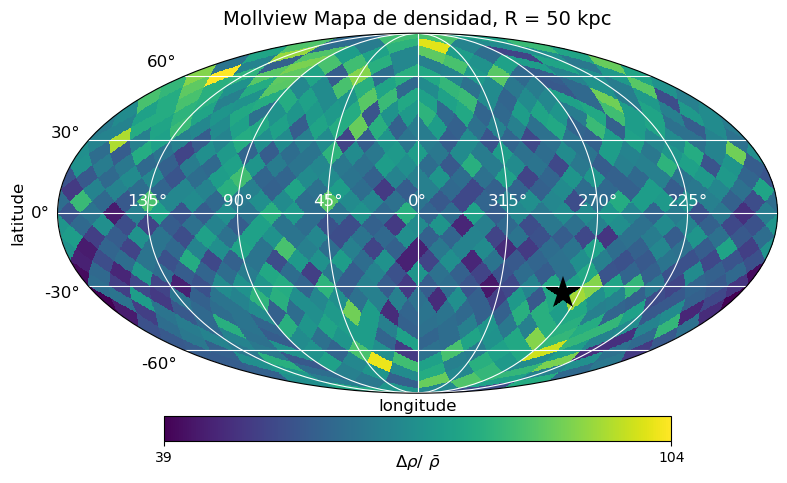

In [23]:
# densidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  mapa_hpx,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

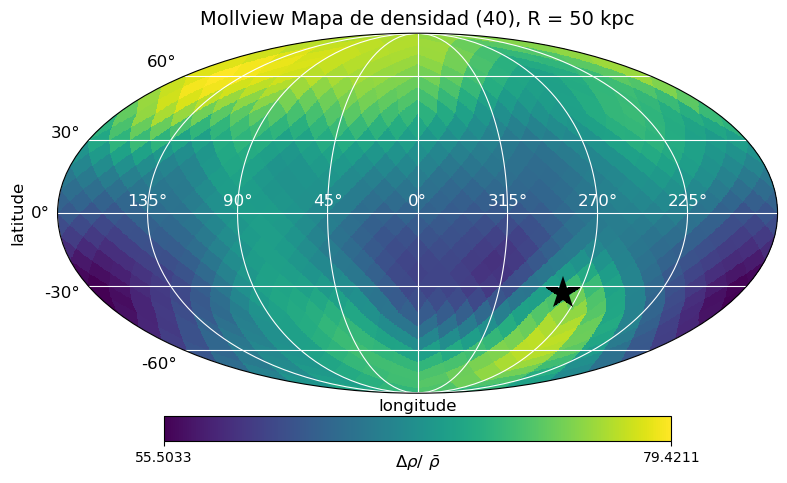

In [24]:
# densidad suavizado

mapa_hpx_smooth = hp.sphtfunc.smoothing(mapa_hpx, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  mapa_hpx_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad (40), R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

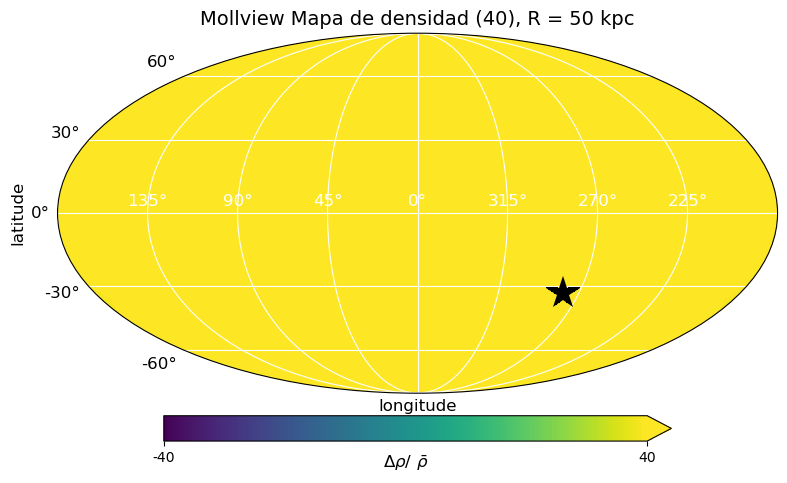

In [25]:
fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  mapa_hpx,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad (40), R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

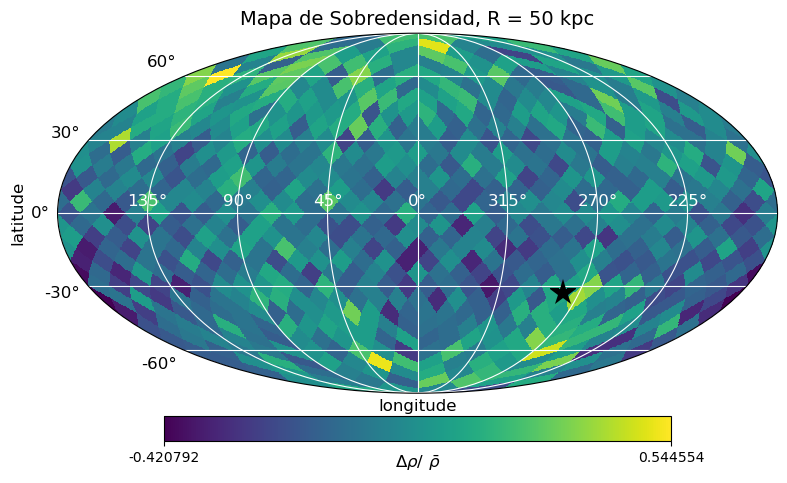

In [26]:
# sobredensidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
  sobredensidad_cat,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa de Sobredensidad, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

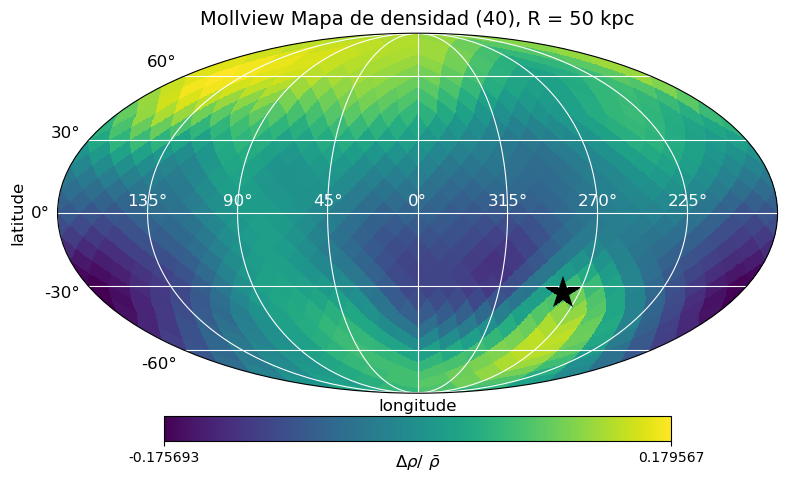

In [27]:
#sobredensidad suavizado
sobre_smooth = hp.sphtfunc.smoothing(sobredensidad_cat, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
    sobre_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad (40), R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

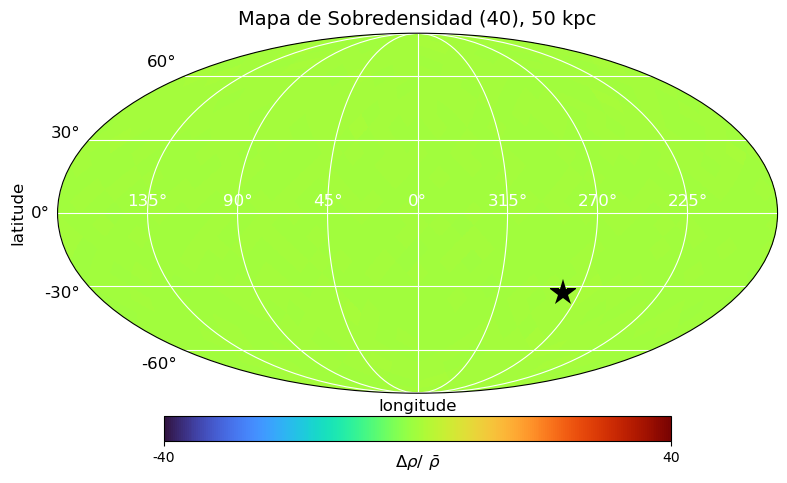

In [28]:
# sobredensidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
  sobredensidad_cat,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa de Sobredensidad (40), 50 kpc',
    cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

# Velocidades promedios

In [29]:
# para el mismo nside

print(
    "Approximate resolution at NSIDE {} is {:.2} deg".format(
        nside, hp.nside2resol(nside, arcmin=True) / 60
    )
)

#numero de pixeles en el mapa

npix = hp.nside2npix(nside)
print(npix)

#OJO
ipix_estrellas_shell = hp.ang2pix(nside, theta,phi, lonlat=False)      # para las correspondientes theta y phi del dataframe de 50 kpc

len(ipix_estrellas_shell)



Approximate resolution at NSIDE 8 is 7.3 deg
768


51712

In [30]:
vr_shell = estrellas_shell['vr2'].values
vtheta_shell = estrellas_shell['vtheta2'].values
vphi_shell = estrellas_shell['vphi2'].values

# para cada componente:
mapa_vr_promedio = np.zeros(len(mapa_hpx))
mapa_vtheta_promedio = np.zeros(len(mapa_hpx))
mapa_vphi_promedio = np.zeros(len(mapa_hpx))

# Para cada pixel en el mapa
for i, ipix in enumerate(ipix_estrellas_shell):
    # Sumar la velocidad promedio de esa componente al pixel correspondiente en el mapa
    # estos mapas no son la vrelocidad promedio
    mapa_vr_promedio[ipix] += vr_shell[i]
    mapa_vtheta_promedio[ipix] += vtheta_shell[i]
    mapa_vphi_promedio[ipix] += vphi_shell[i]

print(mapa_vr_promedio)
print(mapa_vtheta_promedio)
print(mapa_vphi_promedio)


# mapas de velocidad promedio
# Mapas velocidad promedio
a= mapa_vr_promedio/mapa_hpx
b= mapa_vtheta_promedio/mapa_hpx
c= mapa_vphi_promedio/mapa_hpx


[ 1.62632816e+03  2.89094950e+03  1.25091506e+03  1.61212867e+02
  3.23072667e+03  1.53619865e+03  2.10675751e+03  7.82089193e+02
  1.57662305e+03  1.94550916e+03  1.07603753e+03  1.71519962e+03
  1.54279205e+02  2.20391468e+03  2.17582376e+03  1.06924794e+03
  2.71091816e+03  4.39804712e+02  3.35496188e+03  7.56835236e+02
  1.43023868e+03 -2.26970114e+03 -2.68916579e+02  1.90588814e+03
  1.54351760e+03  1.10559663e+03 -8.29812870e+02  1.77021714e+03
  3.76730200e+03  1.30894246e+03  2.31859459e+03  9.32821849e+02
  1.99193193e+03  2.80454577e+03  1.04614004e+03  4.29478250e+02
  2.29789784e+03 -2.06454492e+02  5.23428647e+02  1.80058720e+03
  2.56346968e+02  1.34675557e+03  1.79594806e+03  2.80243711e+03
  1.92621151e+03  2.70656975e+03  1.49107424e+03  1.70263031e+03
  3.08043327e+02  1.12251348e+03  3.37155445e+02  1.79179508e+03
  9.09715428e+02 -6.97699594e+02  5.98054113e+02 -1.07417351e+03
 -7.98198671e+02  1.02248318e+03  1.33111539e+03 -1.03136990e+02
  1.53759845e+03  2.40425

In [31]:

print(np.isnan(a).sum())       # cantidad de valores nan
a[np.isnan(a)] = 0             # se reemplazo los nan por 0
print(np.isnan(a).sum())       # cantidad de nan luego de la modificacion

print(np.isnan(b).sum())
b[np.isnan(b)] = 0
print(np.isnan(b).sum())

print(np.isnan(c).sum())
c[np.isnan(c)] = 0
print(np.isnan(c).sum())


print("Mapa promedio de velocidad radial promedio:", a.mean(), vr_shell.mean())
print("Mapa promedio de velocidad polar promedio:", b.mean(), vtheta_shell.mean())
print("Mapa promedio de velocidad azimutal promedio:", c.mean(), vphi_shell.mean())

0
0
0
0
0
0
Mapa promedio de velocidad radial promedio: -7.895017957342247 -7.171873430020082
Mapa promedio de velocidad polar promedio: -13.727071634884375 -13.858173349418697
Mapa promedio de velocidad azimutal promedio: -0.3203519864692787 -0.23050612314865127


La desviación estándar del mapa velocidad radial promedio es: 23.478352846338222
La desviación estándar del mapa de velocidad polar promedio es: 17.318388623331643
La desviación estándar del mapa velocidad azimutal promedio es: 16.718896035454854


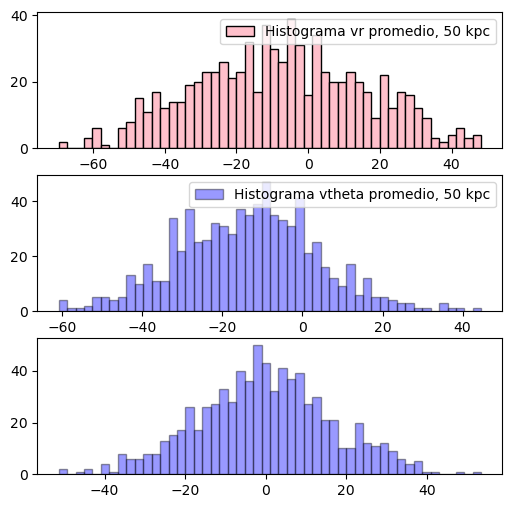

In [32]:
# calculo de los histogramas
histo_vr_prom, bordes_bins = np.histogram(a, bins=50)
histo_vtheta_prom, bordes_bins = np.histogram(b , bins=50)
histo_vphi_prom, bordes_bins = np.histogram(c , bins=50)

# dispersion velocidades
dispersion_vr_prom = np.std(a)
# vthet
dispersion_vtheta_prom = np.std(b )
# vphi
dispersion_vphi_prom = np.std(c )

# print la desviación estandar vr
print("La desviación estándar del mapa velocidad radial promedio es:", dispersion_vr_prom)
# print la desviación vtheta
print("La desviación estándar del mapa de velocidad polar promedio es:", dispersion_vtheta_prom)
# vphi
print("La desviación estándar del mapa velocidad azimutal promedio es:", dispersion_vphi_prom)

#histogramas
fig,ax = plt.subplots(3, figsize=(6,6))
ax[0].hist(a , bins=50, color='pink', edgecolor='black', label='Histograma vr promedio, 50 kpc')
ax[0].legend()

ax[1].hist(b , bins=50,color='blue', alpha=0.4, edgecolor='black', label='Histograma vtheta promedio, 50 kpc')
ax[1].legend()
ax[2].hist( c, bins=50,color='blue', alpha=0.4, edgecolor='black', label='Histograma vphi promedio, 50 kpc')
plt.show()


In [33]:
fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))
a_smooth = hp.sphtfunc.smoothing(a, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

[]

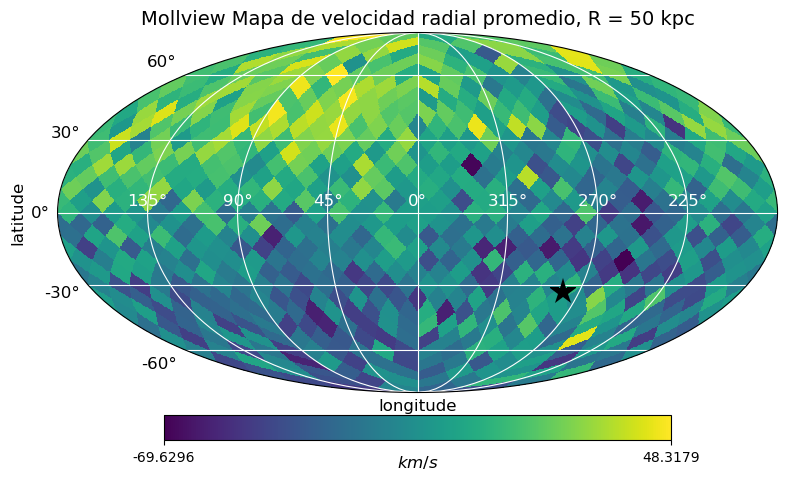

In [34]:
# veocidad radial a

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    a,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de velocidad radial promedio, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

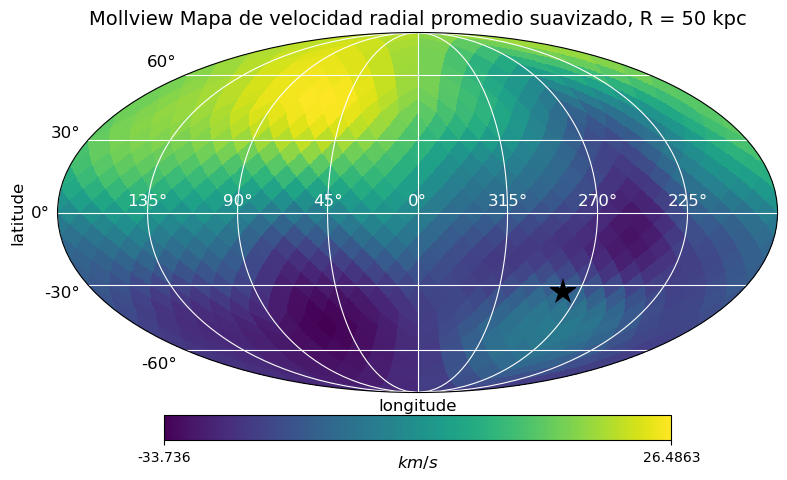

In [35]:
# suavizando
#fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))
a_smooth = hp.sphtfunc.smoothing(a, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

#hp.mollview(a_smooth, flip='astro',title='Mollview Mapa velocidad radial promedio suavizados (40) , 50 kpc')
fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    a_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de velocidad radial promedio suavizado, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

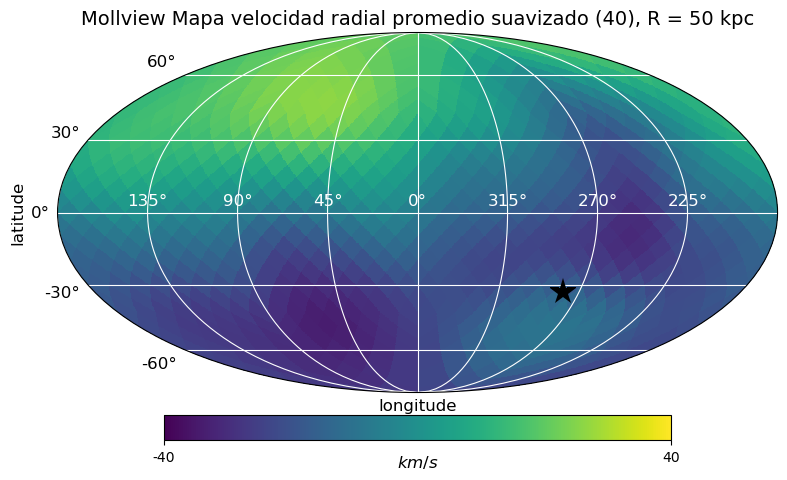

In [36]:
# velocidad radial suavizado en +-40

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    a_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad radial promedio suavizado (40), R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

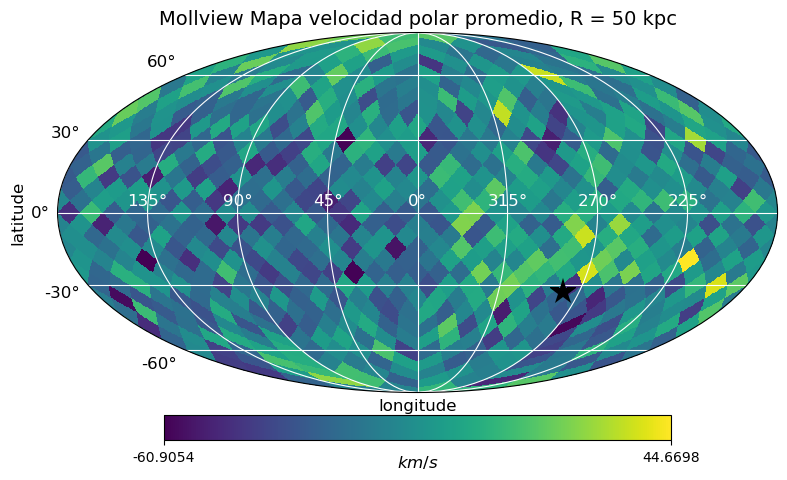

In [37]:
# velocidad polar b

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    b,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad polar promedio, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

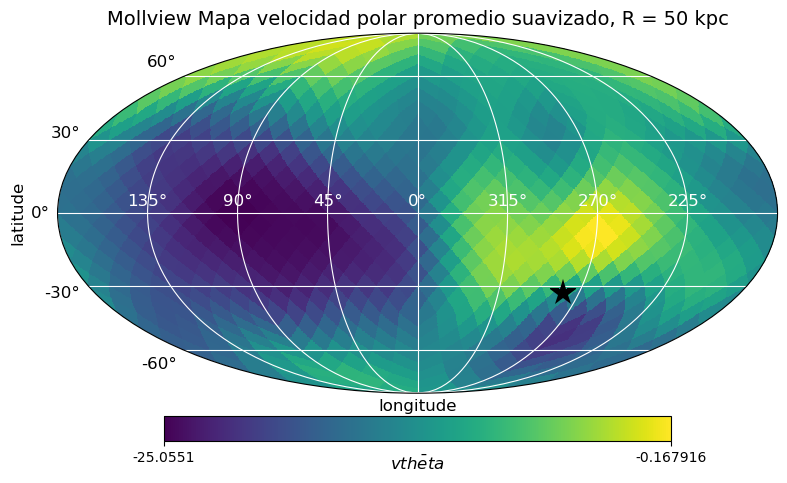

In [38]:
# b suavziado
b_smooth = hp.sphtfunc.smoothing(b, sigma=np.radians(fwhm2sigma(35))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    b_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vtheta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad polar promedio suavizado, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

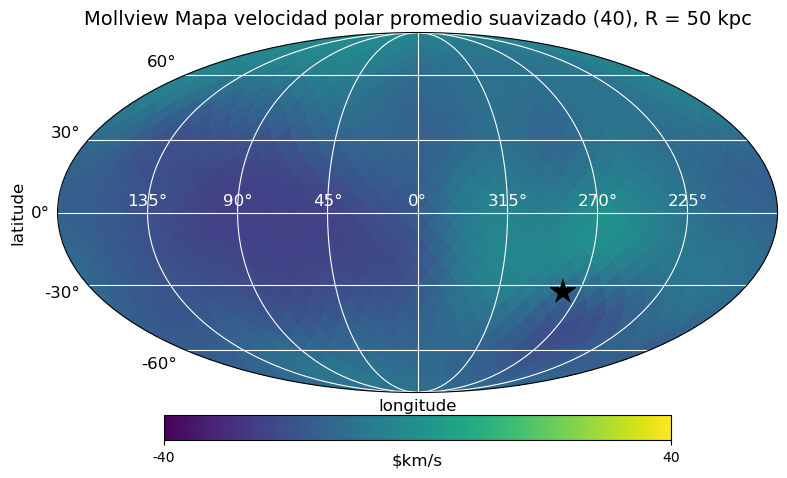

In [39]:
#velocidad polar 40

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    b_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad polar promedio suavizado (40), R = 50 kpc',
   # cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

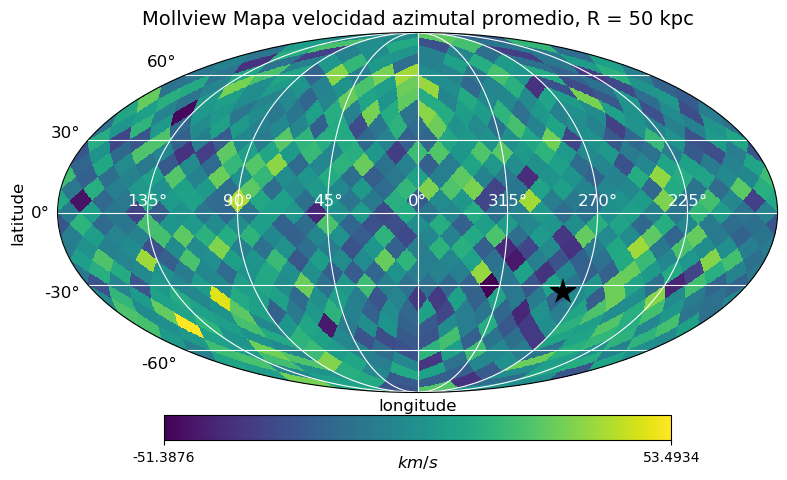

In [40]:
# velocidad azimutal c

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    c,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad azimutal promedio, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

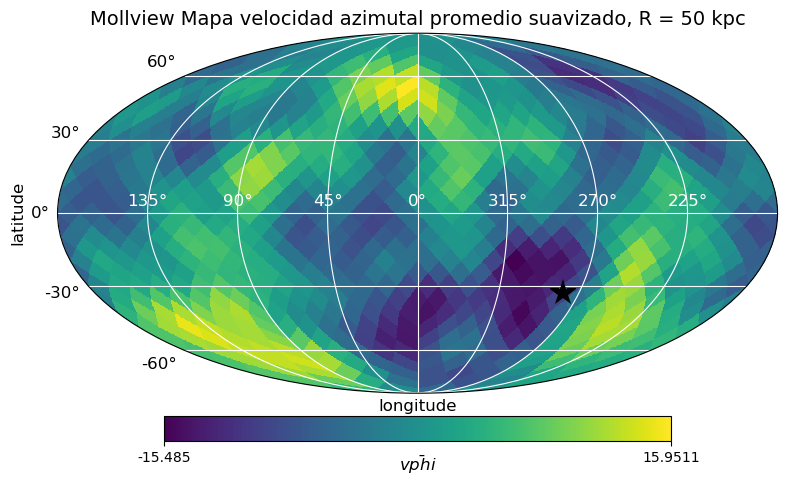

In [41]:
#c suavizado

c_smooth = hp.sphtfunc.smoothing(c, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    c_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad azimutal promedio suavizado, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

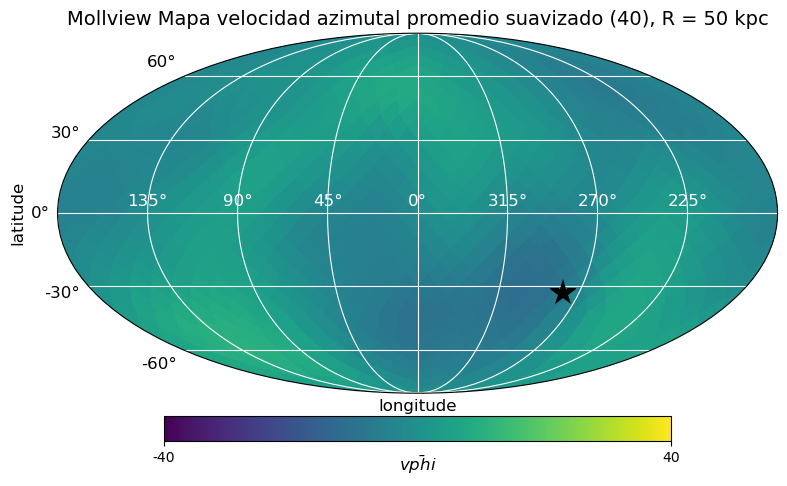

In [42]:
# velocidad azimutal 40

c_smooth = hp.sphtfunc.smoothing(c, sigma=np.radians(fwhm2sigma(35))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    c_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad azimutal promedio suavizado (40), R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

## Cálculo de los espectros de potencia $Cls$ para la densidad, sobredensidad, y velocidades en 50 kpc, con ```anafast```

In [43]:
#densidad
cls_den = hp.anafast(mapa_hpx, lmax=5)
#sobredensidad
cls_sobre = hp.anafast(sobredensidad_cat, lmax=5)

#velocidad radial
cls_vr = hp.anafast(a, lmax=5)
#velocidad polar
cls_vtheta = hp.anafast(b, lmax=5)
#velocidad azimutal
cls_vphi = hp.anafast(c, lmax=5)

print("Cls para la densidad:", cls_den)
print("Cls para la sobredensidad:", cls_sobre)
print("Cls para vr promedio:", cls_vr)
print("Cls velocidad polar promedio:", cls_vtheta)
print("Cls velocidad azimutal promedio:", cls_vphi)

Cls para la densidad: [5.69834245e+04 2.55194822e+01 5.08145980e+01 1.08421359e+01
 3.44378423e+00 2.42650473e+00]
Cls para la sobredensidad: [1.02528727e-07 5.62874571e-03 1.12080050e-02 2.39141316e-03
 7.59583830e-04 5.35205925e-04]
Cls para vr promedio: [782.811316   931.116109   172.92393227  18.95602659   9.10565352
   8.03291553]
Cls velocidad polar promedio: [2364.99009947   98.41453863    9.88990562   29.73603454   12.53277985
   10.01218955]
Cls velocidad azimutal promedio: [ 1.28661458  9.76122921 53.40360277 15.31448508  9.52230822  3.34567034]


<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\e'
<>:46: SyntaxWarning: invalid escape sequence '\p'
<>:11: SyntaxWarning: invalid escape sequence '\e'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:37: SyntaxWarning: invalid escape sequence '\e'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:44: SyntaxWarning: invalid e

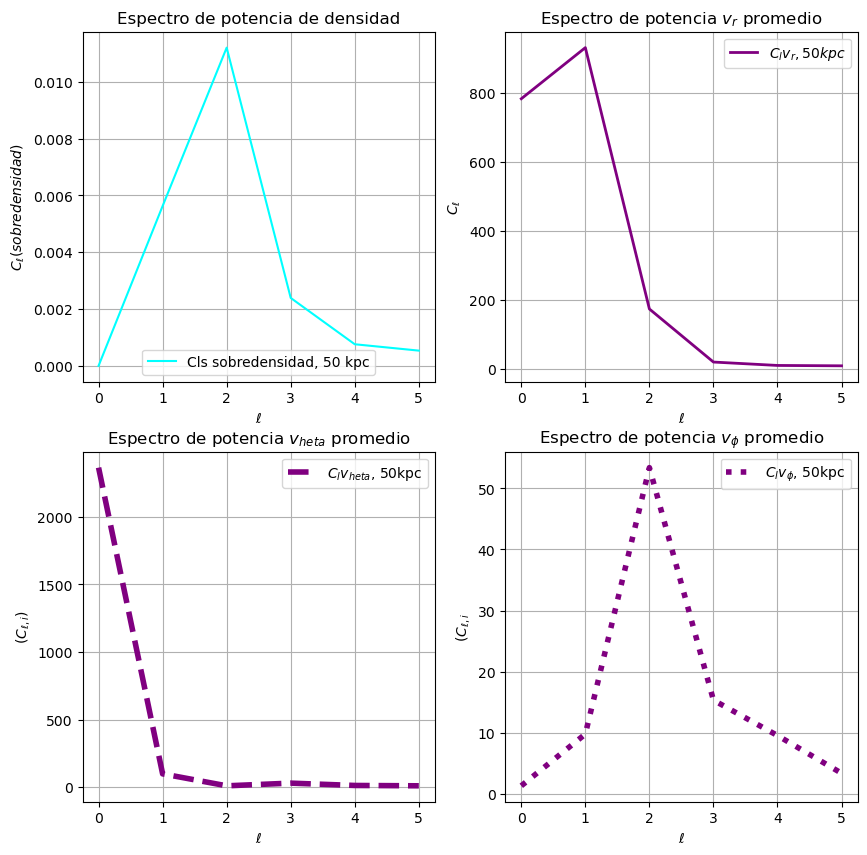

In [44]:
elle = np.arange(len(cls_den))

# como lo usan en el articulo con 2* elle + 1 * cl
# como esta en el tuturial de healpy es elle * (elle + 1) * cl_densidad
#lmax por default: 3*nside-1

fig, ax = plt.subplots(2,2, figsize = (10,10))

############### Cl mapa de densidad
#ax[0,0].plot(elle, cls_hpx_sm, linestyle=None, marker='o', color='purple', lw=2, label='$C_l densidad$, $D = 50$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
#ax[0,0].set_ylim(0,50)
ax[0,0].set_ylabel("$(C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia de densidad')
ax[0,0].plot(elle, cls_sobre, color='cyan', label='Cls sobredensidad, 50 kpc')
#ax[0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$ C_{\ell} (sobredensidad )$")
ax[0,0].legend()
#ax[1].set_ylim(0, 15)
ax[0,0].legend()
ax[0,0].grid()

#plt.plot(elle, elle * (elle + 1) * cl_densidad, color='magenta', lw=2, label='espectro de potencia $D = 50$ kpc')

############### Cl velocidad radial
ax[0,1].plot(elle, cls_vr , color='purple', lw=2, label='$C_l v_r, 50kpc$')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$ C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio')
ax[0,1].legend()
ax[0,1].grid()

############### Cl velocidad polar

ax[1,0].plot(elle,   cls_vtheta,   '--',color='purple', lw=4,  label='$C_l v_{\theta}$, 50kpc')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio')
ax[1,0].legend()
ax[1,0].grid()

############### Cl velocidad azimutal
ax[1,1].plot(elle,  cls_vphi, linestyle='dotted', color='purple', lw=4, label='$C_l v_{\phi}$, 50kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio')
ax[1,1].legend()
ax[1,1].grid()


## Càlculo de los mapas con ```synafast``` (a partir de los cls) para 50 kpc

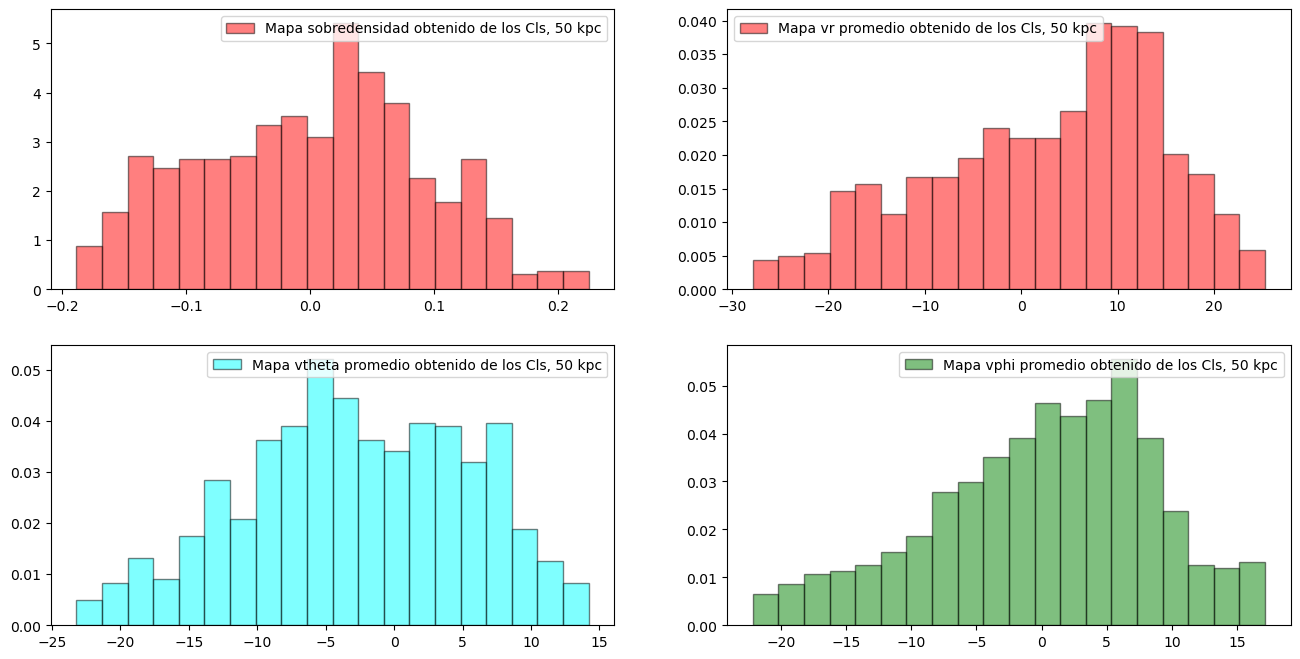

In [45]:
#densidad y sobredensidad

cls2_map_den = hp.synfast(cls_den , nside=8)
cls2_map_sobre = hp.synfast(cls_sobre, nside=8)

#velocidades r, theta y phi respectivamente
cls2_map_vr = hp.synfast(cls_vr , nside=8)
cls2_map_vtheta = hp.synfast(cls_vtheta , nside=8)
cls2_map_vphi = hp.synfast(cls_vphi, nside=8)

#dispersiones densidad y sobre
#disp_cls_den = np.std(cls2_map_den)
disper_cls_sobre = np.std(cls2_map_sobre)
#dispersion velocidades
disper_cls_vr = np.std(cls2_map_vr)
disper_cls_vtheta = np.std(cls2_map_vtheta)
disper_cls_vphi = np.std(cls2_map_vphi)


# histogramas

fig, ax = plt.subplots(2,2, figsize=(16,8))

#ax[0,0].hist(cls2_map_den, density=True, bins=20, color='blue', alpha= 0.5, edgecolor='black', label='Mapa densidad promedio, 50 kpc')
ax[0,0].hist(cls2_map_sobre, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa sobredensidad obtenido de los Cls, 50 kpc')
ax[0,0].legend()
ax[0,1].hist(cls2_map_vr, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa vr promedio obtenido de los Cls, 50 kpc')
ax[0,1].legend()
ax[1,0].hist(cls2_map_vtheta, density=True, bins=20, color='cyan', alpha= 0.5, edgecolor='black', label='Mapa vtheta promedio obtenido de los Cls, 50 kpc')
ax[1,0].legend()
ax[1,1].hist(cls2_map_vphi, density=True, bins=20, color='green', alpha= 0.5, edgecolor='black', label='Mapa vphi promedio obtenido de los Cls, 50 kpc')
ax[1,1].legend()



[]

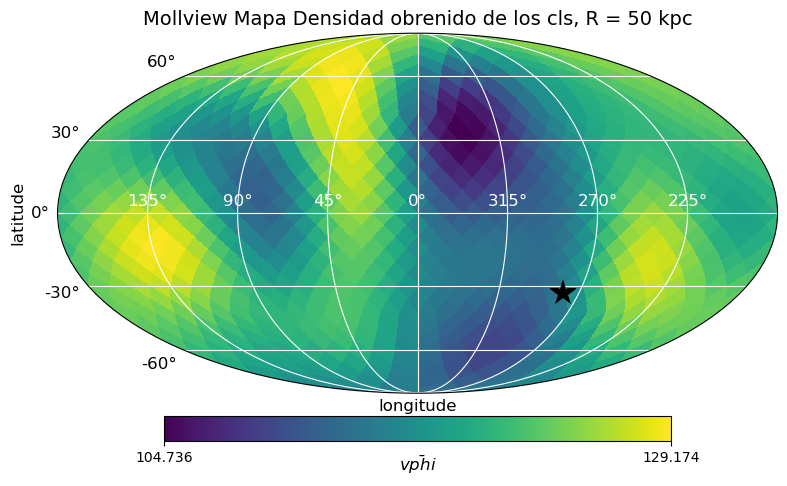

In [46]:
# cls2map densidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls2_map_den,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa Densidad obrenido de los cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

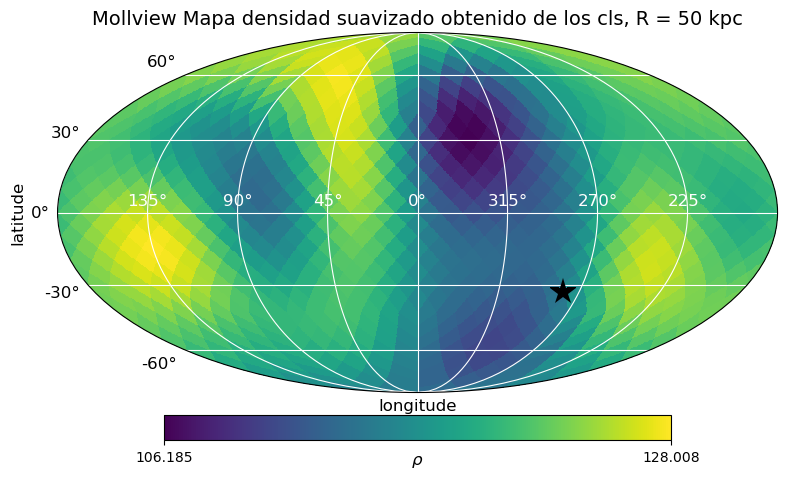

In [47]:
#cls2map densidad suavizado

cls_den_smooth = hp.sphtfunc.smoothing(cls2_map_den, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_den_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"${\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa densidad suavizado obtenido de los cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

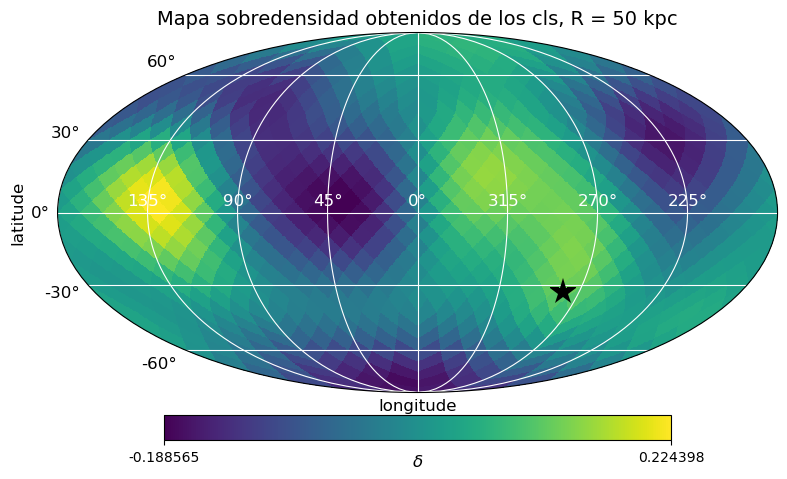

In [50]:
# cls2map sobredensidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls2_map_sobre,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"${\delta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa sobredensidad obtenidos de los cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

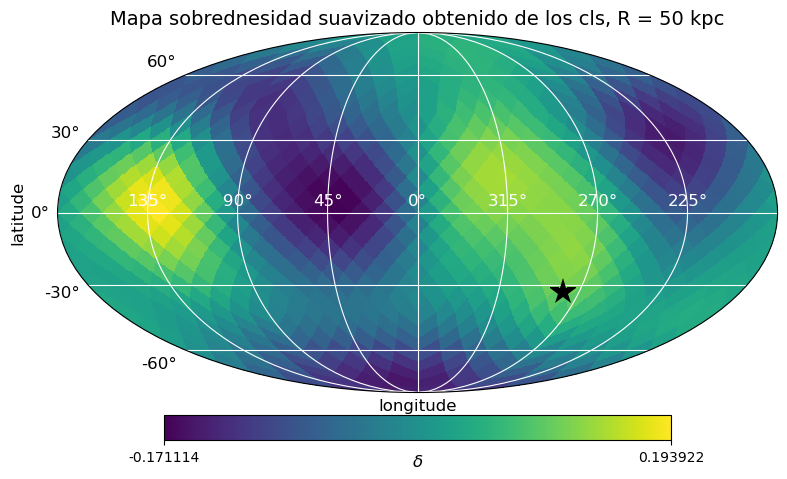

In [117]:
#cls2map sobredensidad suavizado

cls_sobre_smooth = hp.sphtfunc.smoothing(cls2_map_sobre, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_sobre_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"${\delta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa sobrednesidad suavizado obtenido de los cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

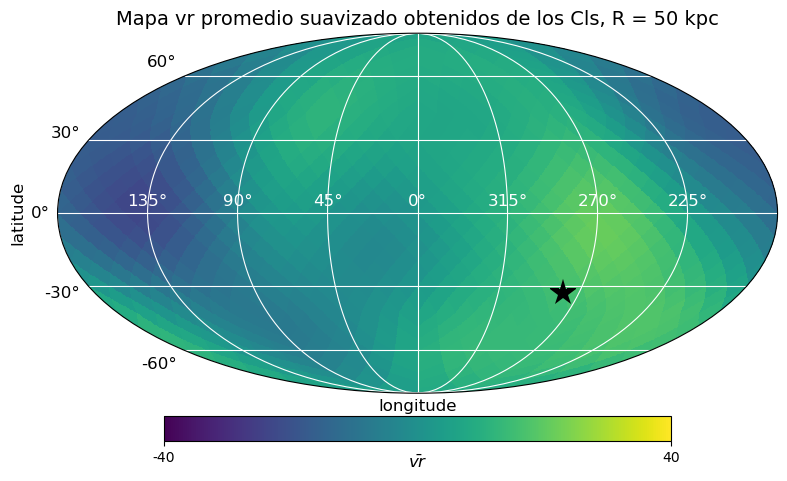

In [118]:
# cls2map vr suavizado


cls_vr_smooth = hp.sphtfunc.smoothing(cls2_map_vr, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vr_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vr}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vr promedio suavizado obtenidos de los Cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

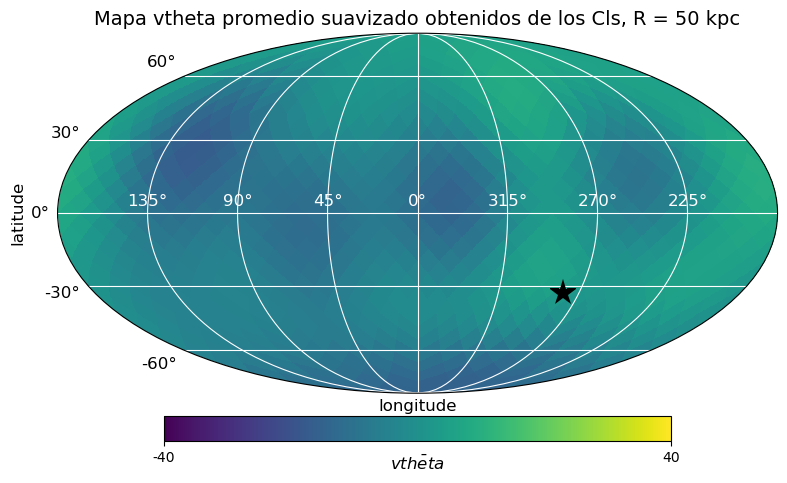

In [119]:
# cls2map vtheta suavizado


cls_vtheta_smooth = hp.sphtfunc.smoothing(cls2_map_vtheta, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vtheta_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vtheta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vtheta promedio suavizado obtenidos de los Cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

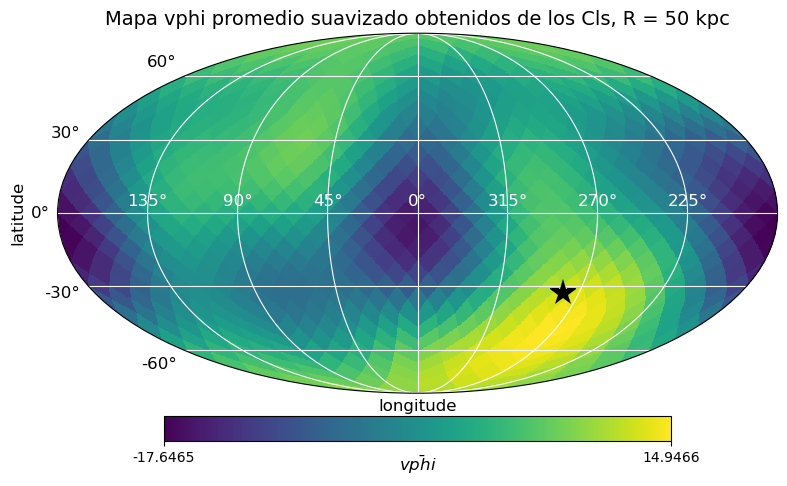

In [120]:
# cls2map vphi suavizado

cls_vphi_smooth = hp.sphtfunc.smoothing(cls2_map_vphi, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vphi_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vphi promedio suavizado obtenidos de los Cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

## Cálculo de los $alm$ de los mapas de densidad y sobredensidad, map_hpx y sobredensidad_cat, con la rutina ```map2alm``` y para cada componente de velocidad

In [121]:
# calculo de los alm con map2alm

#densidad y sobre
map2_alm_den = hp.map2alm(mapa_hpx, lmax=5)
map2_alm_sobre = hp.map2alm(sobredensidad_cat, lmax=5)

#velocidades r, theta, phi
map2_alm_vr = hp.map2alm(a, lmax=5)
map2_alm_vtheta = hp.map2alm(b, lmax=5)
map2_alm_vphi = hp.map2alm(c, lmax=5)

print("$alm$ del mapa de densidad, 50 kpc:",map2_alm_den )
print("$alm$ del mapa de sobredensidad, 50 kpc:", map2_alm_sobre)
print("$alm$ del mapa de velocidad radial promedio, 50 kpc:", map2_alm_vr )
print("$alm$ del mapa de velocidad polar promedio, 50 kpc:", map2_alm_vtheta)
print("$alm$ del mapa de velocidad azimutal promedio, 50 kpc:", map2_alm_vphi )

$alm$ del mapa de densidad, 50 kpc: [ 2.38712012e+02+0.j          8.37120514e+00+0.j
  1.28319825e+01+0.j         -3.37231793e+00+0.j
  1.96135480e-01+0.j          4.87805780e-01+0.j
 -9.52566659e-01+1.52751507j  3.27528685e+00+2.93283697j
 -1.20202869e+00-0.15266097j  7.51952133e-01+2.96813534j
 -8.34756301e-01+0.21144193j -4.32170333e+00-2.58852286j
  5.33439957e+00+1.27553204j -1.75876197e+00-0.0675426j
  1.69615023e+00+1.00820837j -6.07149932e-01+0.58446669j
 -6.09831020e-01-1.04466973j -2.03980315e-01+2.72256901j
  5.54808666e-01+1.1107151j  -9.73600102e-01+0.23294018j
 -3.66622637e-01+0.03609552j]
$alm$ del mapa de sobredensidad, 50 kpc: [ 0.0003202 +0.j          0.12432483+0.j          0.19057402+0.j
 -0.05008393+0.j          0.00291292+0.j          0.00724464+0.j
 -0.01414703+0.02268587j  0.04864287+0.04355698j -0.01785191-0.00226724j
  0.01116761+0.04408122j -0.01239737+0.00314023j -0.06418371-0.03844341j
  0.07922376+0.01894355j -0.02612023-0.00100311j  0.02519035+0.01497339j

### graficando el módulo de los $alm$ con respecto a cada $\ell$.

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/59871637.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


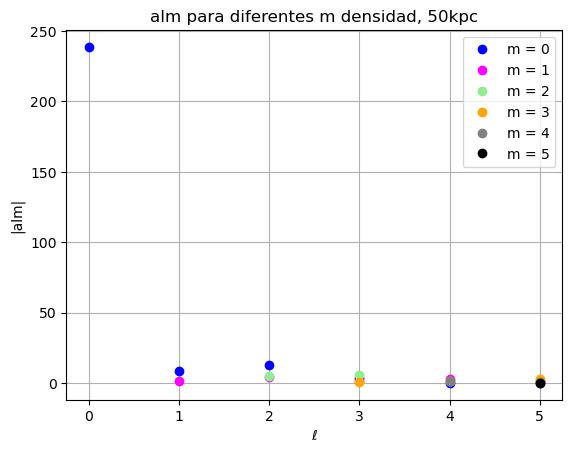

In [122]:
# de los alm hallados en la celda de arriba para densidad
alm_den = map2_alm_den

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_den[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m densidad, 50kpc')
plt.grid()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/728286577.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


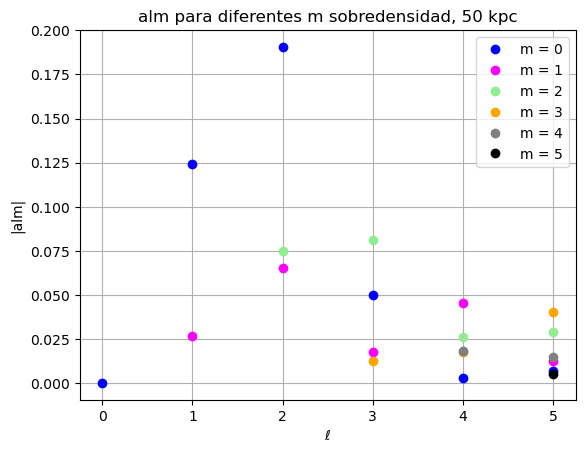

In [123]:
# de los alm hallados en la celda de arriba para la sobredensidad
alm_sobre = map2_alm_sobre

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_sobre[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m sobredensidad, 50 kpc')
plt.grid()
plt.show()

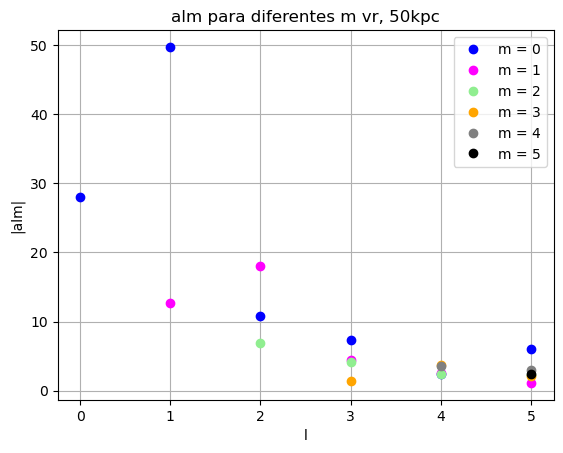

In [124]:
# de los alm hallados en la celda de arriba para vr
alm_vr = map2_alm_vr

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))          #ordena primero por m y luego por l lexicograficamente
l_ordenado = l[indices_ordenados]               # #contien los l ordenados
m_ordenado = m[indices_ordenados]               #contiene los m ordenados
alm_ordenado = alm_vr[indices_ordenados]    #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()

for i, m_val in enumerate(np.unique(m_ordenado)):       #unique para que no haya valores repetidos
    # Seleccionar los índices que corresponden con el orden lexicografico arriba usado.
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('l')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m vr, 50kpc')
plt.grid()
plt.show()

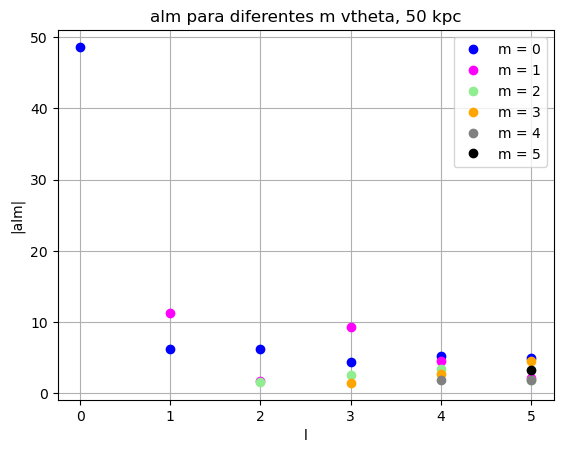

In [125]:
# de los alm hallados en la celda de arriba para vtheta
alm_vtheta = map2_alm_vtheta

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))          #ordena primero por m y luego por l lexicograficamente
l_ordenado = l[indices_ordenados]               # #contien los l ordenados
m_ordenado = m[indices_ordenados]               #contiene los m ordenados
alm_ordenado = alm_vtheta[indices_ordenados]    #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()

for i, m_val in enumerate(np.unique(m_ordenado)):       #unique para que no haya valores repetidos
    # Seleccionar los índices que corresponden con el orden lexicografico arriba usado.
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('l')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m vtheta, 50 kpc')
plt.grid()
plt.show()

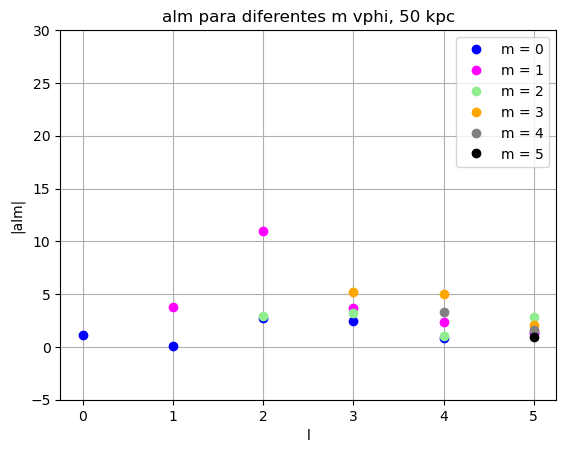

In [126]:
# de los alm hallados en la celda de arriba para vphi
alm_vphi = map2_alm_vphi

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))       #ordena primero por m y luego por l lexicograficamente
l_ordenado = l[indices_ordenados]             #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_vphi[indices_ordenados]    #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()

for i, m_val in enumerate(np.unique(m_ordenado)):
    # Seleccionar los índices que corresponden con el orden lexicografico arriba usado.
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('l')
ax.set_ylabel('|alm|')
ax.set_ylim(-5,30)
ax.legend()
plt.title('alm para diferentes m vphi, 50 kpc')
plt.grid()
plt.show()

## De los $alm$ obtenidos en la celda anterior, calcular los mapas originales con ``` alm2map``` para la densidfad, sobredensidad, y velocidades, en 50 kpc

La desviación estándar del mapa  densidad,  50 kpc : 6.07560546828015
La desviación estándar del mapa de sobredensidad, 50 kpc : 0.09023176729340524
La desviación estándar del mapa velocidad radial promedio, 50 kpc: 17.748127753244574
La desviación estándar del mapa velocidad polar promedio, 50 kpc: 7.854433884203866
La desviación estándar del mapa velocidad azimutal promedio, 50 kpc: 6.4735746142927155


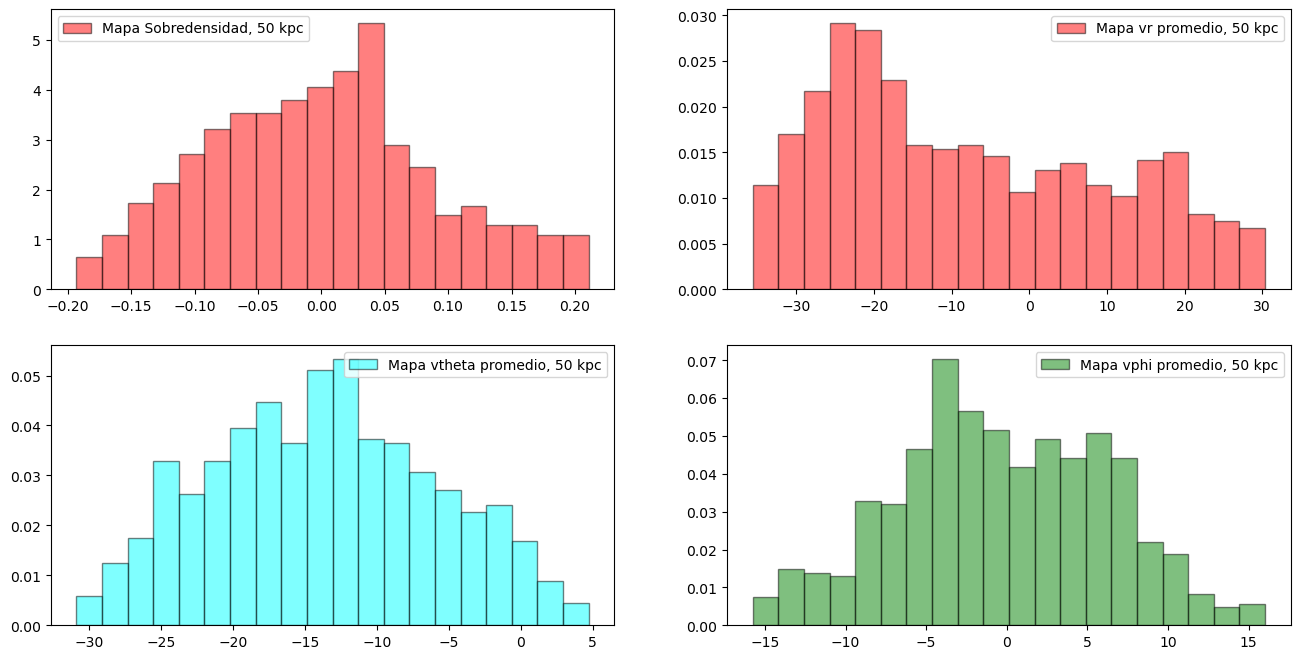

In [127]:
# obtener los mapas de los alm  halldos arriba

# densidad y sobre
alm2_map_den = hp.alm2map(map2_alm_den, nside = 8)
alm2_map_sobre = hp.alm2map(map2_alm_sobre, nside = 8)
#velocidades
alm2_map_vr = hp.alm2map(map2_alm_vr, nside = 8)
alm2_map_vtheta = hp.alm2map(map2_alm_vtheta, nside = 8)
alm2_map_vphi = hp.alm2map(map2_alm_vphi, nside = 8)


#dispersion den y sobre
disp_alm_den = np.std(alm2_map_den)
disp_alm_sobre = np.std(alm2_map_sobre )
#dispersion velocidades
disp_alm_vr = np.std(alm2_map_vr )
disp_alm_vtheta = np.std(alm2_map_vtheta )
disp_alm_vphi = np.std(alm2_map_vphi )

#
print("La desviación estándar del mapa  densidad,  50 kpc :", disp_alm_den)
print("La desviación estándar del mapa de sobredensidad, 50 kpc :", disp_alm_sobre)
print("La desviación estándar del mapa velocidad radial promedio, 50 kpc:", disp_alm_vr)
print("La desviación estándar del mapa velocidad polar promedio, 50 kpc:", disp_alm_vtheta)
print("La desviación estándar del mapa velocidad azimutal promedio, 50 kpc:", disp_alm_vphi)

# histogramas

fig, ax = plt.subplots(2,2, figsize=(16,8))

#ax[0,0].hist(mapa_resul_den, density=True, bins=20, color='blue', alpha= 0.5, edgecolor='black', label='Mapa Densidad resultante (de los Cls), 50 kpc')
ax[0,0].hist(alm2_map_sobre, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa Sobredensidad, 50 kpc')
ax[0,0].legend()
ax[0,1].hist(alm2_map_vr, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa vr promedio, 50 kpc')
ax[0,1].legend()
ax[1,0].hist(alm2_map_vtheta, density=True, bins=20, color='cyan', alpha= 0.5, edgecolor='black', label='Mapa vtheta promedio, 50 kpc')
ax[1,0].legend()
ax[1,1].hist(alm2_map_vphi, density=True, bins=20, color='green', alpha= 0.5, edgecolor='black', label='Mapa vphi promedio, 50 kpc')
ax[1,1].legend()



[]

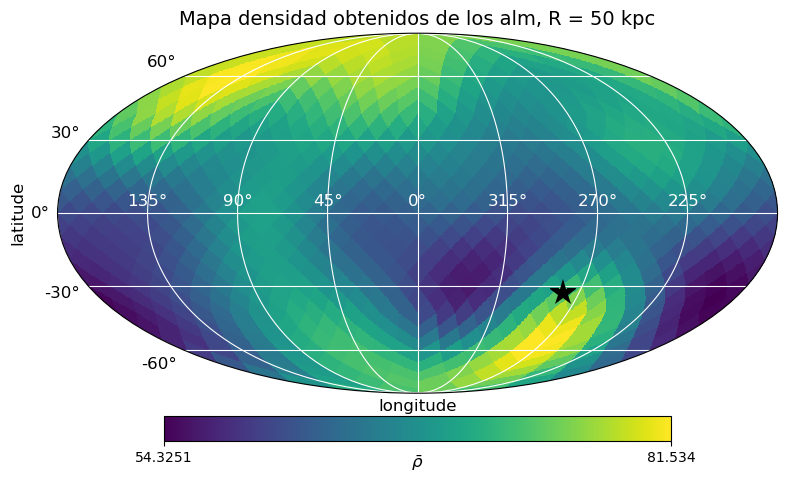

In [128]:
# densidad alm2map

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm2_map_den,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa densidad obtenidos de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

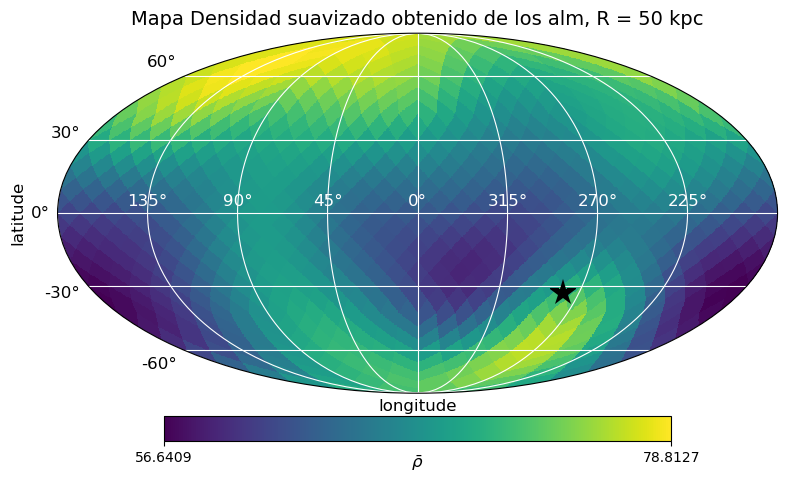

In [129]:
#alm2map densidad suavizado

alm2_den_smooth = hp.sphtfunc.smoothing(alm2_map_den, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg


fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm2_den_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa Densidad suavizado obtenido de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

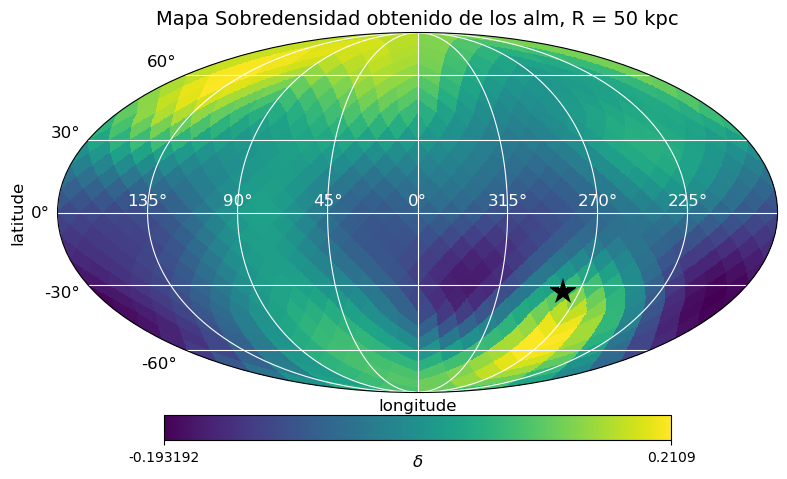

In [130]:
#alm2map sobredensidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm2_map_sobre,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\delta$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa Sobredensidad obtenido de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

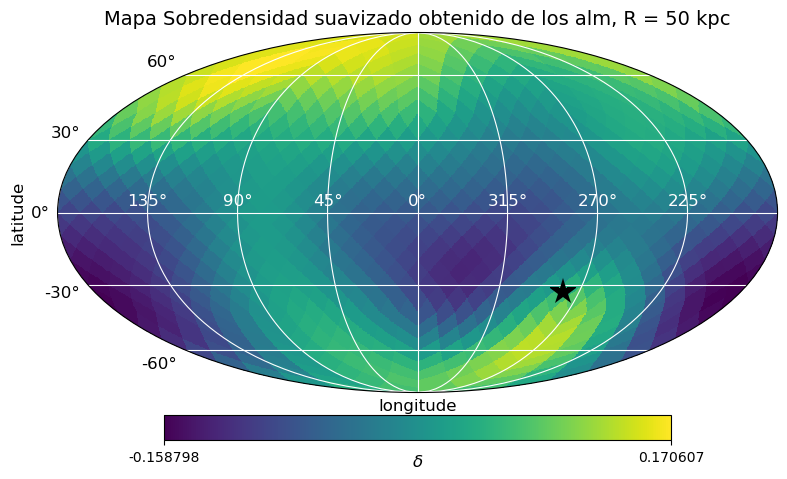

In [131]:
# alm2map sobredensidad suavizado

alm2_sobre_smooth = hp.sphtfunc.smoothing(alm2_map_sobre, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm2_sobre_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\delta$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa Sobredensidad suavizado obtenido de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

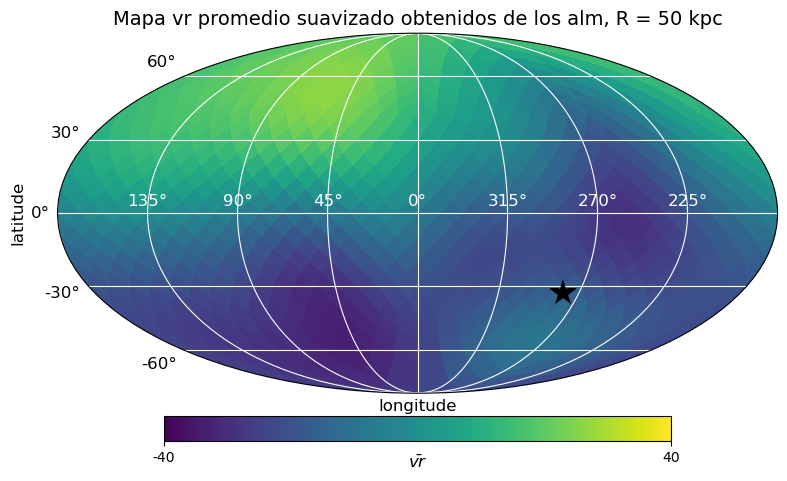

In [132]:
#alm2map vr suavizado


alm_vr_smooth = hp.sphtfunc.smoothing(alm2_map_vr, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm_vr_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vr}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vr promedio suavizado obtenidos de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()


[]

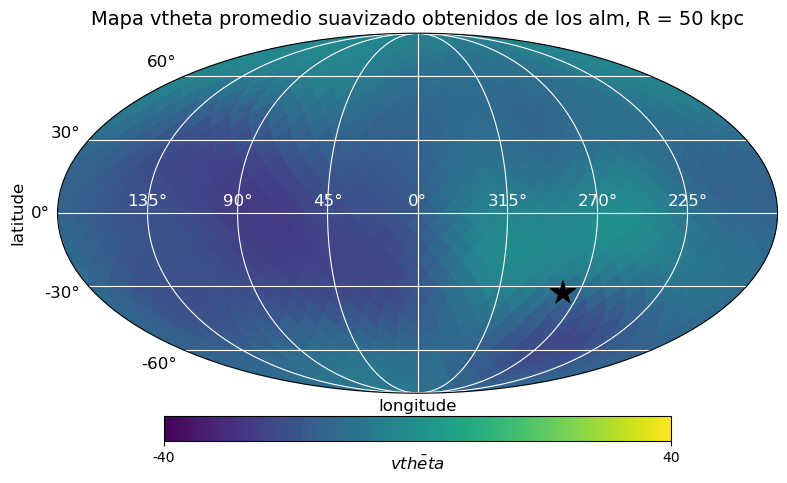

In [133]:
#alm2map vtheta suavizado


alm_vtheta_smooth = hp.sphtfunc.smoothing(alm2_map_vtheta, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm_vtheta_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vtheta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vtheta promedio suavizado obtenidos de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()


[]

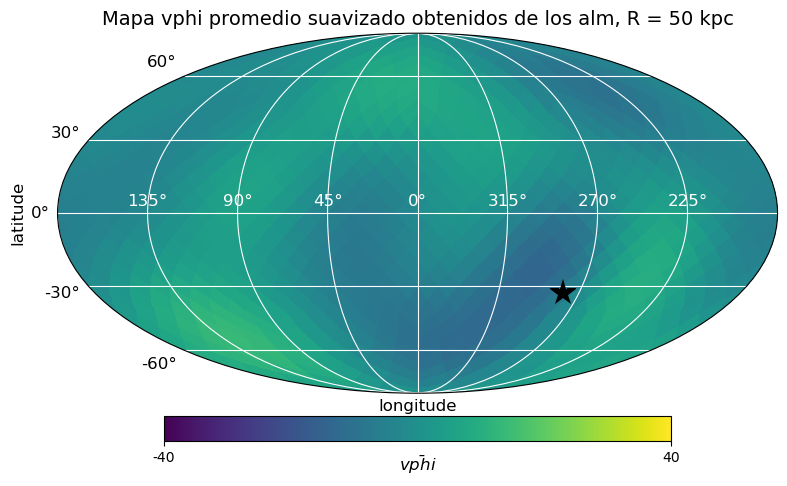

In [134]:
#alm2map vphi suavizado


alm_vphi_smooth = hp.sphtfunc.smoothing(alm2_map_vphi, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    alm_vphi_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vphi promedio suavizado obtenidos de los alm, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()


# Para la densidad y sobredensidad en un radio de 75 kpc

In [135]:
# no en 70 kpc porque dan diviones por 0

radio75_interno_shell = 72.5
radio75_externo_shell = 77.5

# nuevo dataframe estrellas_shell75

estrellas_shell75 = mc[(mc['R'] >= radio75_interno_shell)  & (mc['R'] <= radio75_externo_shell)]

estrellas_shell75


,x,y,z,vx,vy,vz,R,theta,phi,phi2,cotheta,vr2,vtheta2,vphi2
32,-47.316544,-35.868263,48.313995,-115.024048,190.890305,31.336401,76.548218,0.683045,3.790225,-142.836086,0.887752,1.432083,-39.234644,-221.608217
34,-11.029136,-61.545609,-37.958000,198.650604,-55.480873,-211.605270,73.145837,-0.545606,4.535068,-100.159716,2.116402,126.538609,170.727185,205.322159
68,3.985337,-12.279812,-71.932823,8.855239,133.327484,-77.155472,73.082199,-1.393209,5.026208,-72.019481,2.964006,54.022261,135.760851,49.580105
80,-32.795929,4.617523,-68.055206,94.442795,200.095840,19.464720,75.686231,-1.117882,3.001716,171.985685,2.688678,-46.218017,50.489005,-211.308820
135,-30.460232,64.641663,19.591484,-17.851204,-194.393753,-151.872604,74.095860,0.267589,2.011153,115.230597,1.303207,-202.407979,101.983959,99.010944
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999960,-68.511604,-10.124344,24.371185,-24.067173,144.888107,136.838150,73.418642,0.338368,3.288306,-171.593919,1.232428,47.901888,-128.206838,-146.849881
999968,9.302028,32.781712,66.548607,220.893448,98.079720,18.995043,74.765536,1.097559,1.294308,74.158358,0.473238,87.394166,128.999757,-185.730129
999969,10.118794,-48.560566,55.360008,-91.219139,-144.796417,-49.642689,74.332019,0.840185,4.917824,-78.229438,0.730611,45.204592,124.841061,-118.838481
999972,-9.126480,-18.703703,-70.098640,-86.345261,-70.533020,326.673828,73.122777,-1.282195,4.258427,-116.010083,2.852992,-284.345522,-190.041615,-46.669148


In [136]:
phi = estrellas_shell75['phi'].values
theta = estrellas_shell75['cotheta'].values

#mapa_hpx75 = cat_to_hpx(phi, theta ,  nside, radec=True)      #lon = l, lat = b en grados
mapa_hpx75 = cat_to_hpx(theta ,phi,  nside, radec=False)      #lon = l, lat = b en radianes

#sobredensidad cat_to

sobredensidad_cat75 = (mapa_hpx75 - np.mean(mapa_hpx75))/(np.mean(mapa_hpx75))

Dispersión mapa densidad, 75 kpc: 9.086098346359796
Dispersión mapa sobredensidad, 75 kpc: 0.18802876508957544


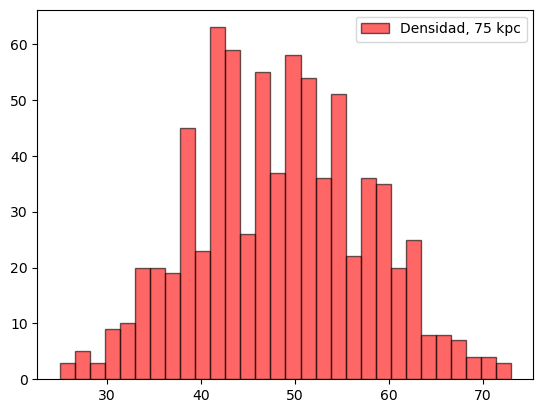

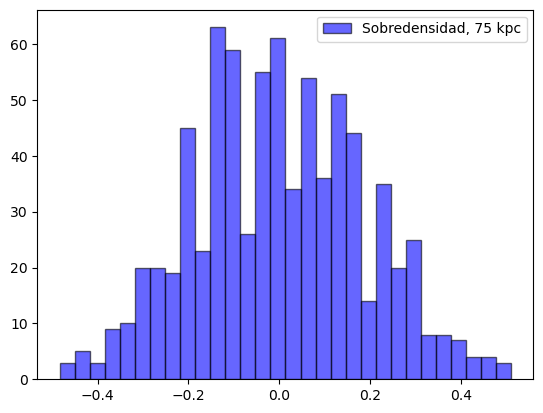

In [137]:
#dispersion densidad y sobre
disp_den75 = np.std(mapa_hpx75)
disp_sobre75 = np.std(sobredensidad_cat75)
print("Dispersión mapa densidad, 75 kpc:", disp_den75)
print("Dispersión mapa sobredensidad, 75 kpc:",disp_sobre75)

plt.hist(mapa_hpx75, bins=30, color='red',alpha= 0.6, edgecolor='black', label='Densidad, 75 kpc')
plt.legend()
plt.show()
plt.hist(sobredensidad_cat75, bins=30, color='blue',alpha= 0.6, edgecolor='black', label='Sobredensidad, 75 kpc')
plt.legend()

In [138]:
#from healpy.newvisufunc import projview, newprojplot
#fwhm2sigma = lambda fwhm: fwhm / np.sqrt(8*np.log(2))


[]

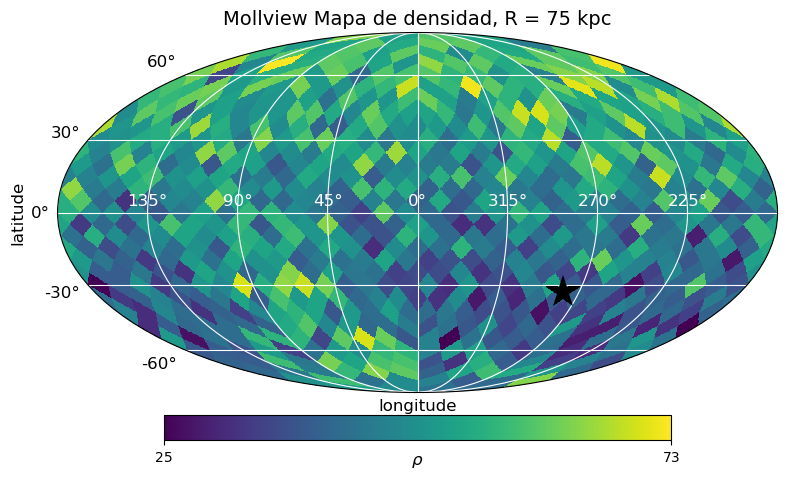

In [139]:
# densidad

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  mapa_hpx75,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\rho$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

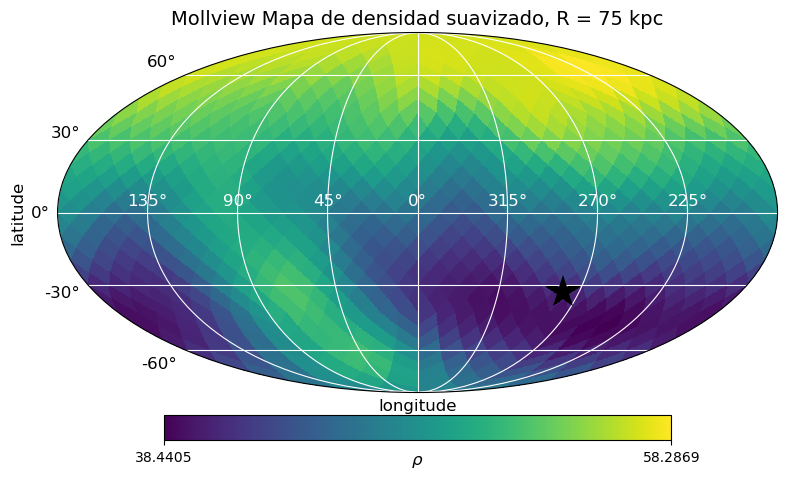

In [140]:
# densidad suavizado

mapa_hpx75_smooth = hp.sphtfunc.smoothing(mapa_hpx75, sigma=np.radians(fwhm2sigma(30)))

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  mapa_hpx75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\rho$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de densidad suavizado, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

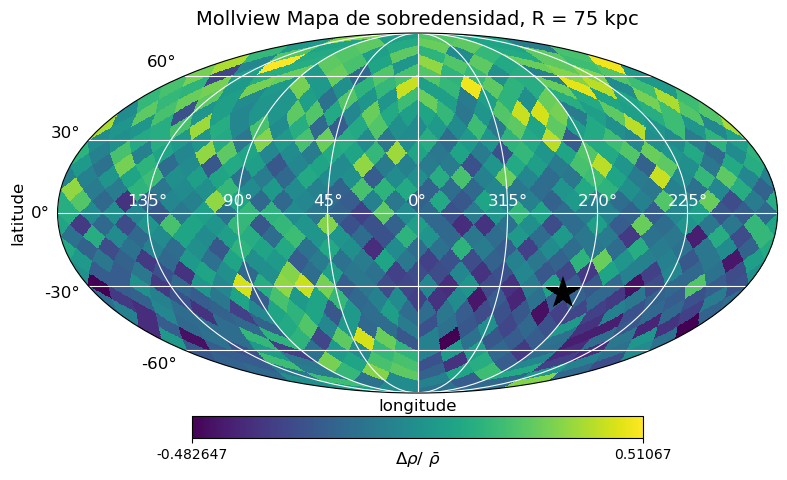

In [141]:
# sobredensidad 75 kpc

fig=plt.figure(figsize=(8,5))
ax = fig.add_subplot()

hp.projview(
  sobredensidad_cat75,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de sobredensidad, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

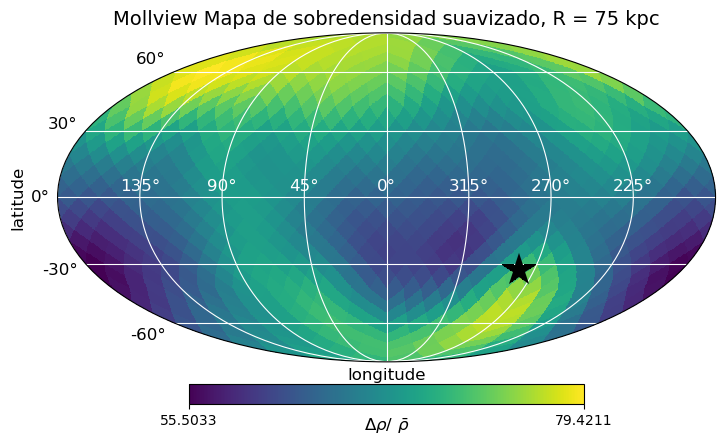

In [142]:
#sobredensidad suavizado

# densidad suavizado

sobre75_smooth = hp.sphtfunc.smoothing(mapa_hpx, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()

hp.projview(
  sobre75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\Delta \rho /\ \bar{\rho}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa de sobredensidad suavizado, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

### Velocidades en 75 kpc

In [143]:
#recordando mismo nside

#para un numero de pixeles fijo
# npix = hp.nside2npix(nside)
#print(npix)
#numero de pixeles en el mapa

ipix_estrellas_shell75 = hp.ang2pix(nside, theta, phi, lonlat=False)      #
len(ipix_estrellas_shell75)



37112

In [144]:
vr_shell75 = estrellas_shell75['vr2'].values
vtheta_shell75 = estrellas_shell75['vtheta2'].values
vphi_shell75 = estrellas_shell75['vphi2'].values

# para cada componente:
mapa_vr_promedio75 = np.zeros(len(mapa_hpx75))
mapa_vtheta_promedio75 = np.zeros(len(mapa_hpx75))
mapa_vphi_promedio75 = np.zeros(len(mapa_hpx75))

# Para cada pixel en el mapa
for i, ipix in enumerate(ipix_estrellas_shell75):
    # Sumar la velocidad promedio de esa componente al pixel correspondiente en el mapa
    # estos mapas no son la vrelocidad promedio aún, son simplemente la suma de cada velocidad por pixel
    mapa_vr_promedio75[ipix] += vr_shell75[i]
    mapa_vtheta_promedio75[ipix] += vtheta_shell75[i]
    mapa_vphi_promedio75[ipix] += vphi_shell75[i]


#print("Mapa vr, 75 kpc:", mapa_vr_promedio75)
#print("Mapa vtheta, 75 kpc:", mapa_vtheta_promedio75)
#print("Mapa vphi, 75 kpc:", mapa_vphi_promedio75)


# Calcular el promedio dividiendo por el número de estrellas en cada pixel (densidad) OJO
d= mapa_vr_promedio75/mapa_hpx75
e= mapa_vtheta_promedio75/mapa_hpx75
f= mapa_vphi_promedio75/mapa_hpx75

print("Mapa velocidad radial promedio, 75 kpc:", d)
print("Mapa velocidad polar promedio, 75 kpc:", e)
print("Mapa velocidad azimutal promedio, 75 kps:", f)

Mapa velocidad radial promedio, 75 kpc: [ 6.19286601e+01  3.64737887e+01  3.63073174e+01  3.99707052e+01
  2.64798518e+01  2.07329862e+01 -1.54330074e+00  4.38190479e+01
 -5.05811646e+00 -6.78387457e-01  3.06366244e+01  1.55927140e+01
  2.76735023e+01  9.22931504e+00  4.08339562e+01  4.08089218e+01
  3.09050385e+01  3.70435977e+01  3.80520887e+01  5.02413276e+01
  3.16101168e+01  1.00051584e+01  1.78708702e+01  2.14821822e+01
  2.14736636e+01  1.61044187e+01  5.34448166e+01  1.70769834e+01
  3.23604397e+01  4.18792633e+01  6.08985544e+01  3.47512590e+01
  2.54833740e+01  2.79263460e+01  2.75490246e+01  2.96119540e+01
  2.77922416e+01  2.48156316e+01  2.40433707e+01  2.30112143e+01
  1.93497268e+01  5.66496571e+01  1.44609420e+01  2.47921379e+01
  3.04749191e+01  3.70564878e+01  3.05350438e+01  4.89554791e+01
  1.32370180e+01  2.51194298e+01  2.69411243e+01  2.45644166e+01
  7.00905010e+00  9.70258226e+00  1.76932750e+01 -7.06176388e+00
  1.20189589e+01  9.09082915e+00  8.78080187e+00  

In [145]:

print(np.isnan(d).sum())       # cantidad de valores nan
d[np.isnan(d)] = 0             # se reemplazo los nan por 0
print(np.isnan(d).sum())       # cantidad de nan luego de la modificacion

print(np.isnan(e).sum())
e[np.isnan(e)] = 0
print(np.isnan(e).sum())

print(np.isnan(f).sum())
f[np.isnan(f)] = 0
print(np.isnan(f).sum())


print("Mapa promedio de velocidad radial promedio:", a.mean(), vr_shell.mean())
print("Mapa promedio de velocidad polar promedio:", b.mean(), vtheta_shell.mean())
print("Mapa promedio de velocidad azimutal promedio:", c.mean(), vphi_shell.mean())

0
0
0
0
0
0
Mapa promedio de velocidad radial promedio: -7.895017957342247 -7.171873430020082
Mapa promedio de velocidad polar promedio: -13.727071634884375 -13.858173349418697
Mapa promedio de velocidad azimutal promedio: -0.3203519864692787 -0.23050612314865127


[]

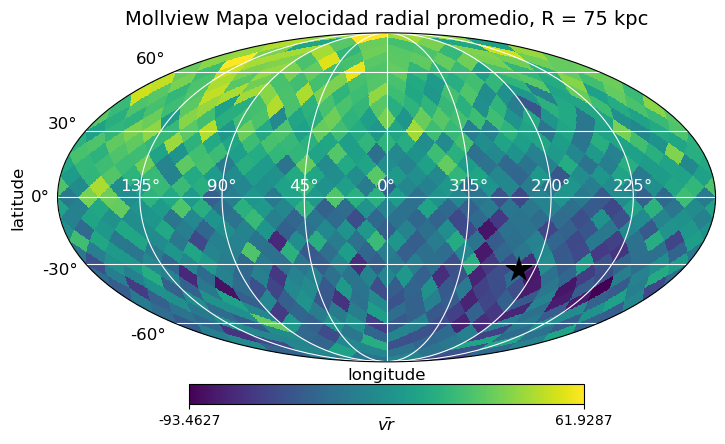

In [146]:
# velocidad vr 75 kpc


fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()
hp.projview(
    d,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vr}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad radial promedio, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

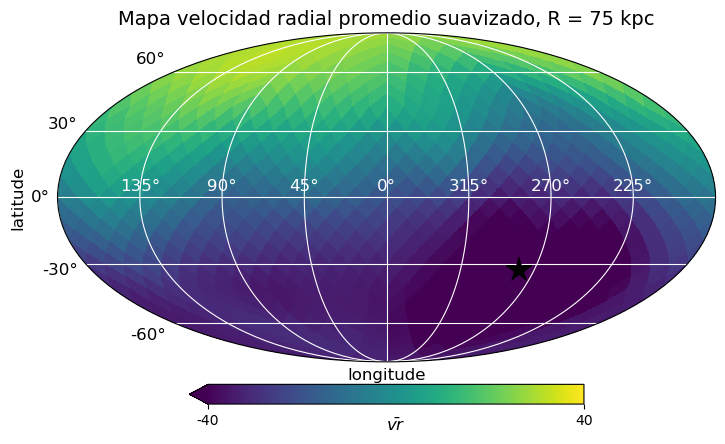

In [147]:
# velocidad radial 75 suavizado

vr75_smooth = hp.sphtfunc.smoothing(d, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg


fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()
hp.projview(
    vr75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vr}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa velocidad radial promedio suavizado, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

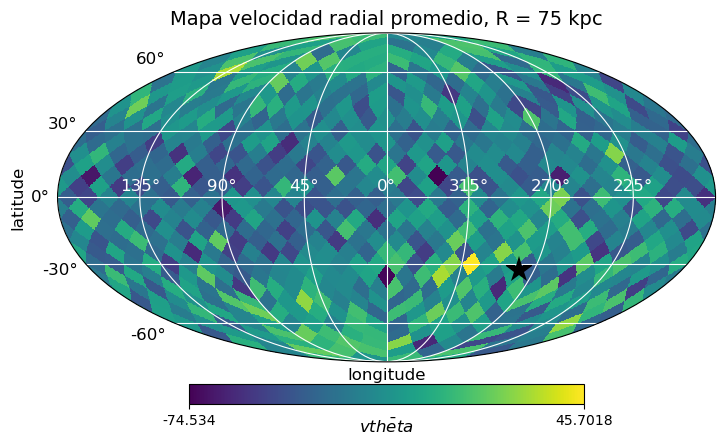

In [148]:
# velocidad polar 75 kpc


fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()
hp.projview(
    e,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vtheta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa velocidad radial promedio, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

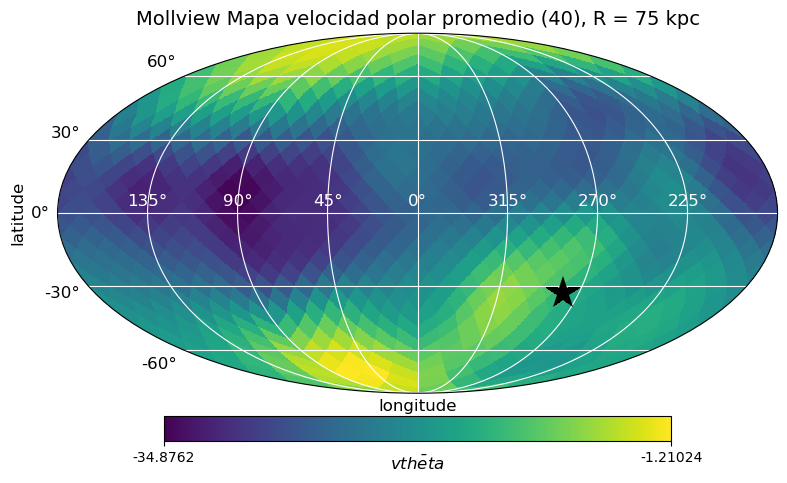

In [149]:
# vpolar suavizado 75

vtheta75_smooth = hp.sphtfunc.smoothing(e, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()

hp.projview(
  vtheta75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vtheta}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad polar promedio (40), R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-50,
    #max=50,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

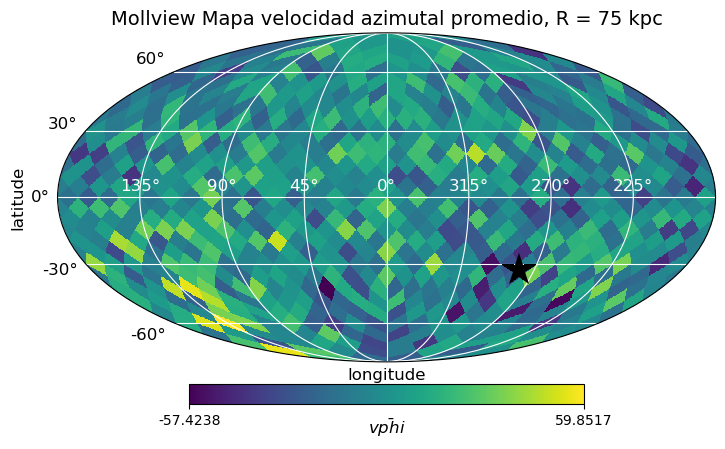

In [150]:
# v azimultal 75

fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()

hp.projview(
  f,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vphi}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad azimutal promedio, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

[]

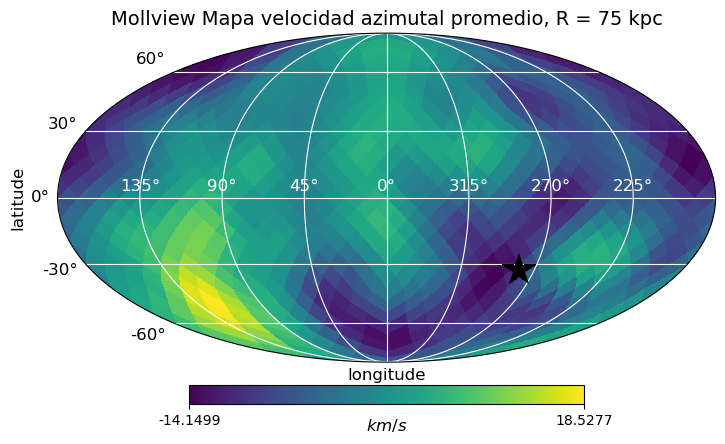

In [151]:
vphi75_smooth = hp.sphtfunc.smoothing(f, sigma=np.radians(fwhm2sigma(25))) # correspond to 30 deg

fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()

hp.projview(
  vphi75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$km/s$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mollview Mapa velocidad azimutal promedio, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-50,
    #max=50,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=25,markeredgewidth=0.015)

plt.plot()

## Cálculo de los espectros de potencia $Cls$ para la densidad, sobredensidad y velocidades en 75 kpc, con  ```anafast```

In [152]:
#densidad
cls_den75 = hp.anafast(mapa_hpx75, lmax=5)
#sobredensidad
cls_sobre75 = hp.anafast(sobredensidad_cat75, lmax=5)

#velocidad radial
cls_vr75 = hp.anafast(d, lmax=5)
#velocidad polar
cls_vtheta75 = hp.anafast(e, lmax=5)
#velocidad azimutal
cls_vphi75 = hp.anafast(f, lmax=5)

print("Cls para la densidad, 75 kpc:", cls_den75)
print("Cls para la sobredensidad, 75 kpc:", cls_sobre75)
print("Cls velocidad radial promedio, 75 kpc:" , cls_vr75)
print("Cls velocidad polar promedio, 75 kpc:",cls_vtheta75)
print("Cls velocidad azimutal promedio, 75 kpc:",cls_vphi75)

Cls para la densidad, 75 kpc: [2.93494305e+04 8.89621488e+01 2.14220840e+01 5.19969793e+00
 2.03103323e+00 8.99933475e-01]
Cls para la sobredensidad, 75 kpc: [1.16249594e-07 3.80977200e-02 9.17393121e-03 2.22675192e-03
 8.69782849e-04 3.85393271e-04]
Cls velocidad radial promedio, 75 kpc: [2547.96829381 2153.83117158   88.97673906   13.90551127    6.49530887
    5.22545282]
Cls velocidad polar promedio, 75 kpc: [4835.36275745   32.54149861  106.49794298   33.03524613    5.59962257
    7.32171005]
Cls velocidad azimutal promedio, 75 kpc: [ 8.35924119 45.46390075 54.64067138 12.1293291   6.88973143  9.57942089]


<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\e'
<>:44: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:10: SyntaxWarning: invalid escape sequence '\e'
<>:12: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:35: SyntaxWarning: invalid escape sequence '\e'
<>:36: SyntaxWarning: invalid escape sequence '\e'
<>:42: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid e

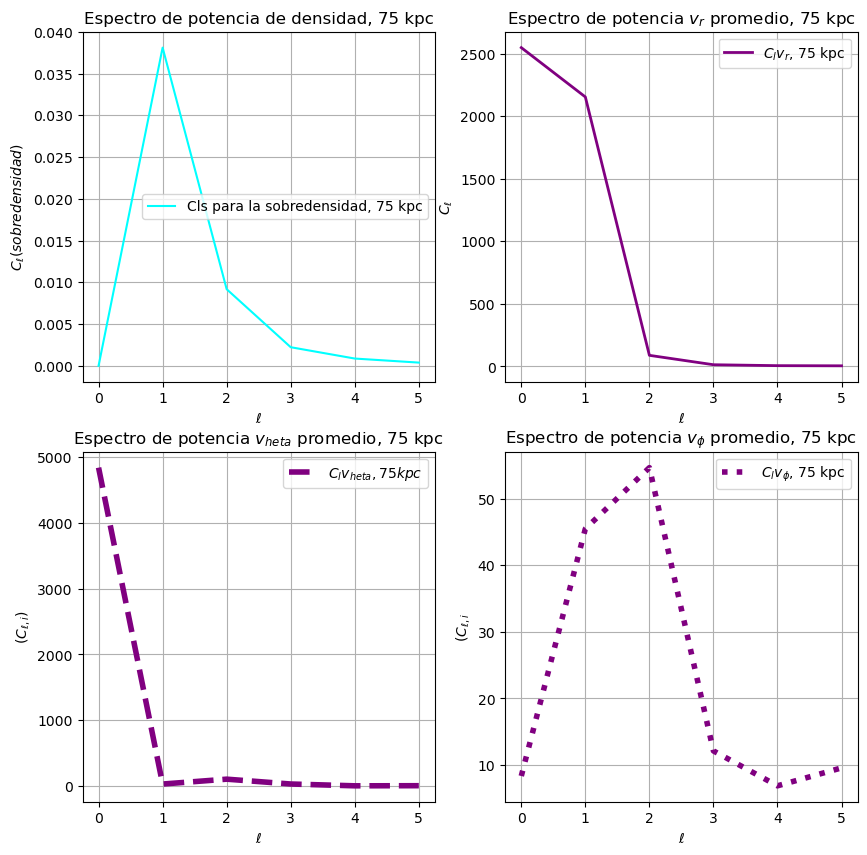

In [153]:


# como lo usan en el articulo con 2* elle + 1 * cl
# como esta en el tuturial de healpy es elle * (elle + 1) * cl_densidad
#lmax por default: 3*nside-1

elle = np.arange(len(cls_sobre75))
fig, ax = plt.subplots(2,2, figsize = (10,10))

############### Cl mapa de densidad
#ax[0,0].plot(elle, cls_hpx_sm, linestyle=None, marker='o', color='purple', lw=2, label='$C_l densidad$, $D = 50$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
#ax[0,0].set_ylim(0,50)
ax[0,0].set_ylabel("$(C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia de densidad, 75 kpc')
ax[0,0].plot(elle, cls_sobre75, color='cyan', label='Cls para la sobredensidad, 75 kpc')
#ax[0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$ C_{\ell} (sobredensidad )$")
ax[0,0].legend()
#ax[1].set_ylim(0, 15)
ax[0,0].legend()
ax[0,0].grid()

#plt.plot(elle, elle * (elle + 1) * cl_densidad, color='magenta', lw=2, label='espectro de potencia $D = 50$ kpc')

############### Cl velocidad radial
ax[0,1].plot(elle, cls_vr75 , color='purple', lw=2, label='$C_l v_r$, 75 kpc')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$ C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio, 75 kpc')
ax[0,1].legend()
ax[0,1].grid()

############### Cl velocidad polar

ax[1,0].plot(elle,   cls_vtheta75,   '--',color='purple', lw=4,  label='$C_l v_{\theta}, 75 kpc$')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio, 75 kpc')
ax[1,0].legend()
ax[1,0].grid()

############### Cl velocidad azimutal
ax[1,1].plot(elle,  cls_vphi75, linestyle='dotted', color='purple', lw=4, label='$C_l v_{\phi}$, 75 kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio, 75 kpc')
ax[1,1].legend()
ax[1,1].grid()

## Calcular los mapas de densidad, sobredensidad y velocidades, con ```synfast```, en 75 kpc

La desviación estándar del mapa  densidad,  75 kpc : 5.05666981846918
La desviación estándar del mapa de sobredensidad, 75 kpc : 0.10127448753799267
La desviación estándar del mapa velocidad radial promedio, 75 kpc: 7.878630298475022
La desviación estándar del mapa velocidad polar promedio, 75 kpc: 6.5619873385040846
La desviación estándar del mapa velocidad azimutal promedio, 75 kpc: 5.780011059829715


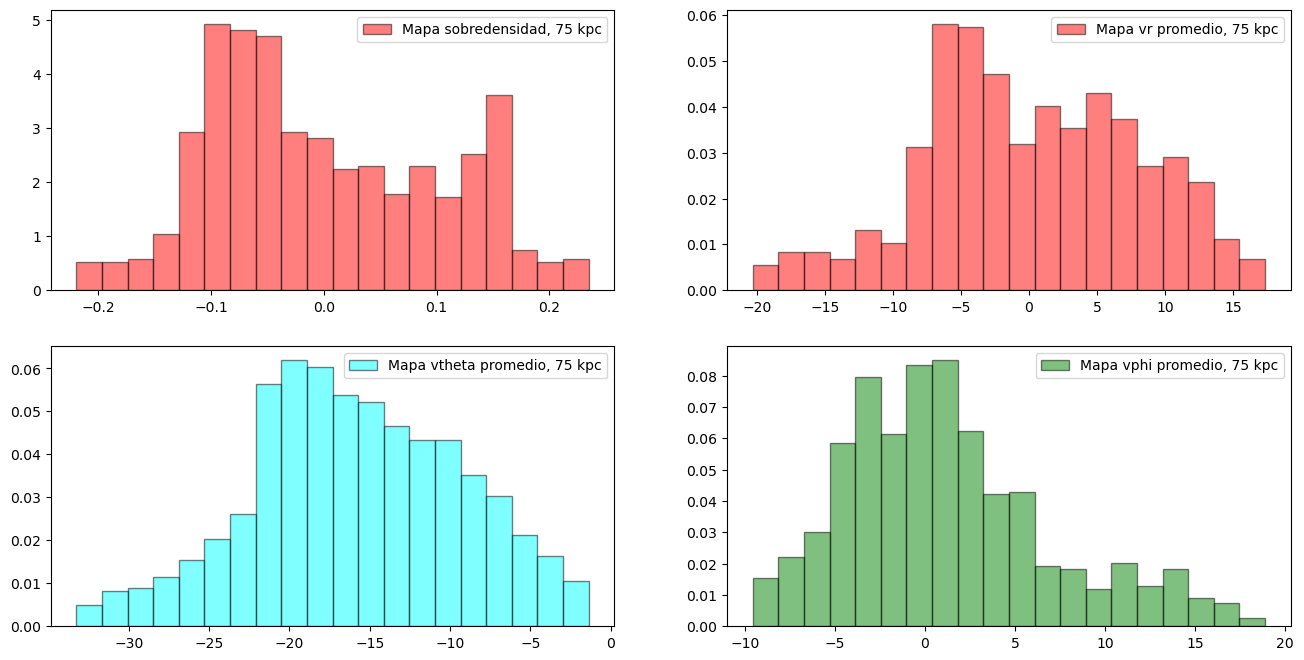

In [154]:
#densidad y sobredensidad
cls2_map_den75 = hp.synfast(cls_den75 , nside=8)
cls2_map_sobre75 = hp.synfast(cls_sobre75, nside=8)

#velocidades r, theta y phi respectivamente
cls2_map_vr75 = hp.synfast(cls_vr75 , nside=8)
cls2_map_vtheta75 = hp.synfast(cls_vtheta75 , nside=8)
cls2_map_vphi75 = hp.synfast(cls_vphi75, nside=8)

#dispersiones densidad y sobre
disp_cls_den75 = np.std(cls2_map_den75)
disp_cls_sobre75 = np.std(cls2_map_sobre75)
#dispersion velocidades
disp_cls_vr75 = np.std(cls2_map_vr75)
disp_cls_vtheta75 = np.std(cls2_map_vtheta75)
disp_cls_vphi75 = np.std(cls2_map_vphi75)

###
print("La desviación estándar del mapa  densidad,  75 kpc :", disp_cls_den75)
print("La desviación estándar del mapa de sobredensidad, 75 kpc :", disp_cls_sobre75)
print("La desviación estándar del mapa velocidad radial promedio, 75 kpc:", disp_cls_vr75)
print("La desviación estándar del mapa velocidad polar promedio, 75 kpc:", disp_cls_vtheta75)
print("La desviación estándar del mapa velocidad azimutal promedio, 75 kpc:", disp_cls_vphi75)


# histogramas

fig, ax = plt.subplots(2,2, figsize=(16,8))

#ax[0,0].hist(cls2_map_den75, density=True, bins=20, color='blue', alpha= 0.5, edgecolor='black', label='Mapa densidad promedio, 75 kpc')
ax[0,0].hist(cls2_map_sobre75, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa sobredensidad, 75 kpc')
ax[0,0].legend()
ax[0,1].hist(cls2_map_vr75, density=True, bins=20, color='red', alpha= 0.5,edgecolor='black', label='Mapa vr promedio, 75 kpc')
ax[0,1].legend()
ax[1,0].hist(cls2_map_vtheta75, density=True, bins=20, color='cyan', alpha= 0.5, edgecolor='black', label='Mapa vtheta promedio, 75 kpc')
ax[1,0].legend()
ax[1,1].hist(cls2_map_vphi75, density=True, bins=20, color='green', alpha= 0.5, edgecolor='black', label='Mapa vphi promedio, 75 kpc')
ax[1,1].legend()

[]

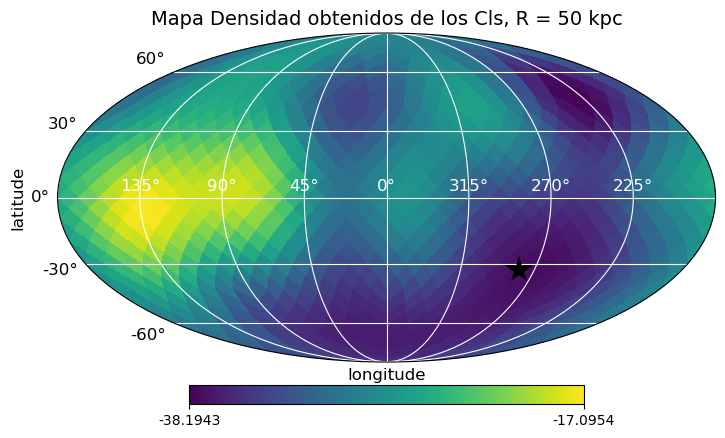

In [155]:
# cls2map densidad 75 kpc

fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()
hp.projview(
    cls2_map_den75,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa Densidad obtenidos de los Cls, R = 50 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

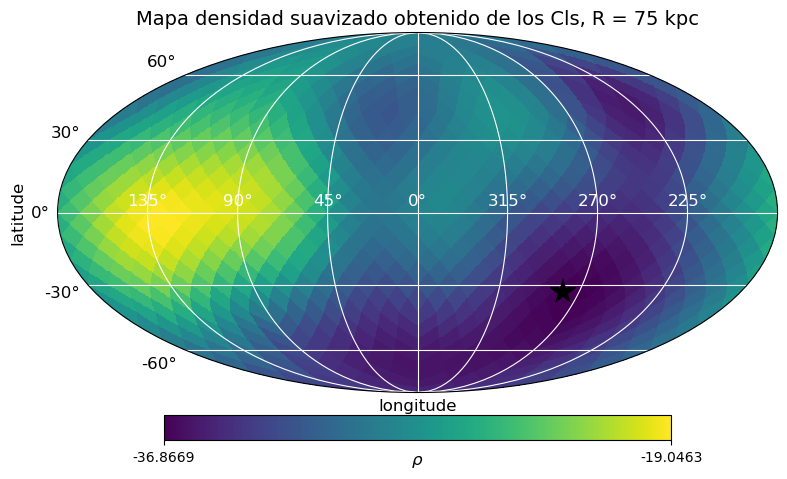

In [156]:
# cls2map densidad suavizado 75 kpc

cls_den75_smooth = hp.sphtfunc.smoothing(cls2_map_den75, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_den75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\rho$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa densidad suavizado obtenido de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

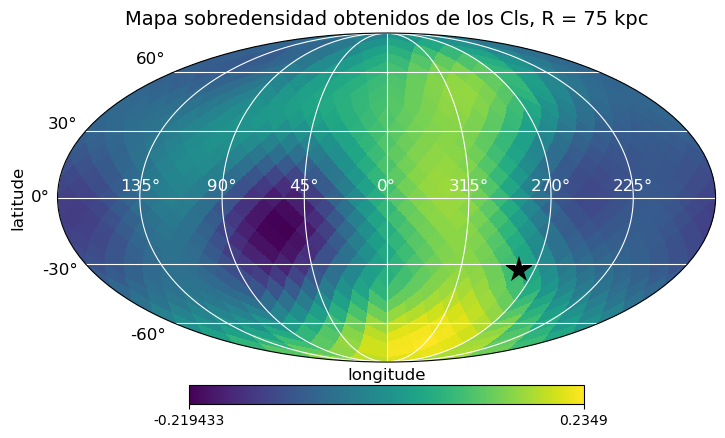

In [157]:
# cls2map sobre en 75 kpc


fig=plt.figure(figsize=(7,5))
ax = fig.add_subplot()
hp.projview(
    cls2_map_sobre75,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa sobredensidad obtenidos de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

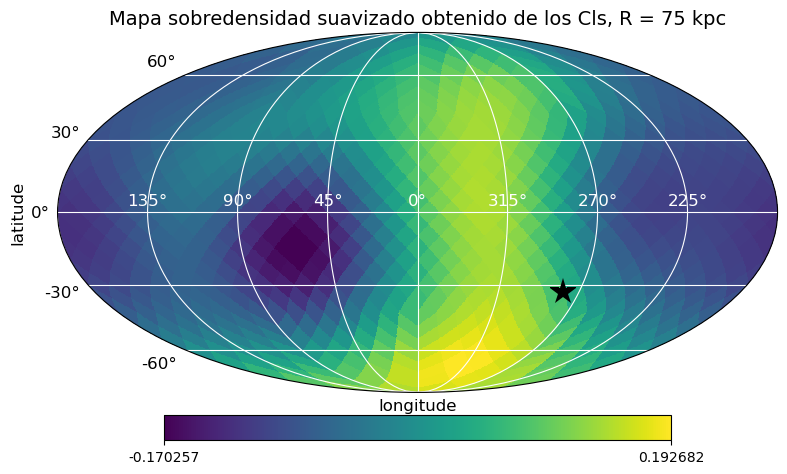

In [158]:
# cls2map cls sobre suavziados 75 kpc

cls_sobre75_smooth = hp.sphtfunc.smoothing(cls2_map_sobre75, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_sobre75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa sobredensidad suavizado obtenido de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

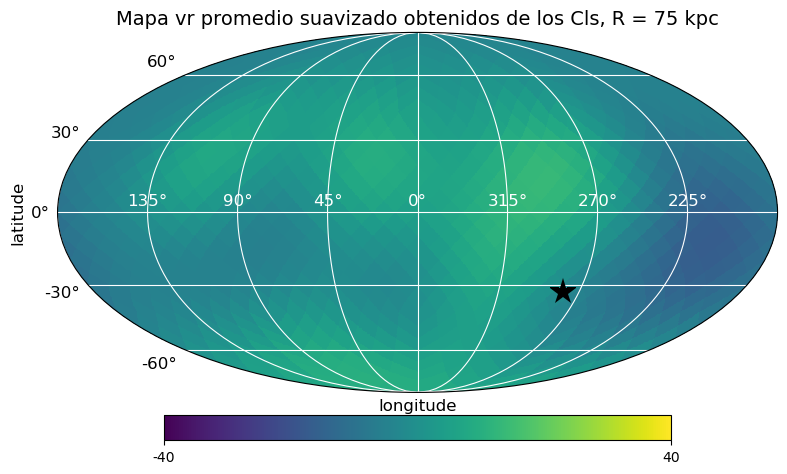

In [159]:
# cls2map vr suavizado

cls_vr75_smooth = hp.sphtfunc.smoothing(cls2_map_vr75, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vr75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vr promedio suavizado obtenidos de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

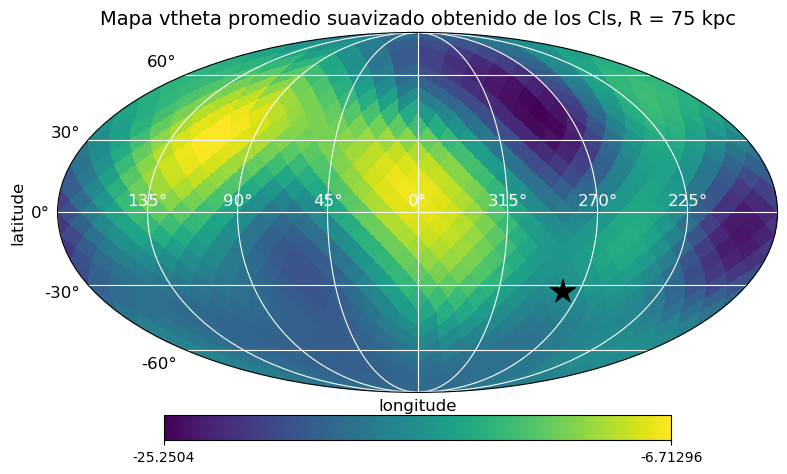

In [160]:
# cls2map vtheta suavizado

cls_vtheta75_smooth = hp.sphtfunc.smoothing(cls2_map_vtheta75, sigma=np.radians(fwhm2sigma(40))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vtheta75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vtheta promedio suavizado obtenido de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-50,
    #max=50,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

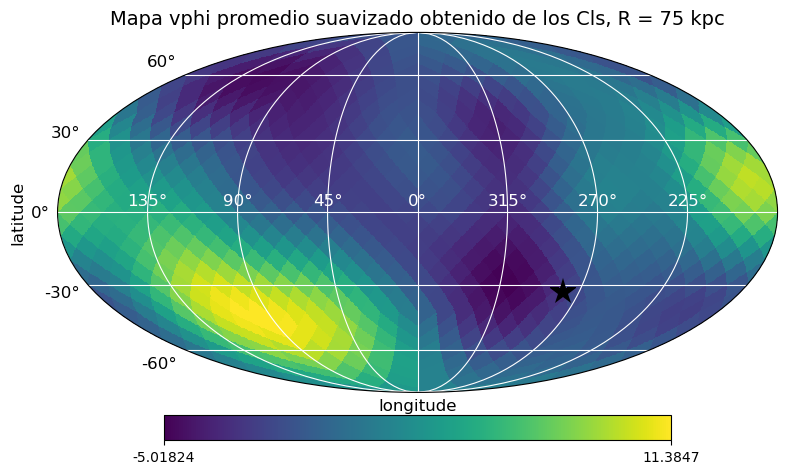

In [161]:
# cls2map vphi suavizado 75 kpc

cls_vphi75_smooth = hp.sphtfunc.smoothing(cls2_map_vphi75, sigma=np.radians(fwhm2sigma(40))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    cls_vphi75_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa vphi promedio suavizado obtenido de los Cls, R = 75 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

## Cálcular los $alm$ de la densidad, sobredensidad, y velocicades a partir de ```map2alm```, en un R= 75 kpc

In [162]:
# calculo de los alm con map2alm

#densidad y sobre
map2_alm_den75 = hp.map2alm(mapa_hpx75, lmax=5)
map2_alm_sobre75 = hp.map2alm(sobredensidad_cat75, lmax=5)

#velocidades r, theta, phi
map2_alm_vr75 = hp.map2alm(d, lmax=5)
map2_alm_vtheta75 = hp.map2alm(e, lmax=5)
map2_alm_vphi75 = hp.map2alm(f, lmax=5)

print("$alm$ mapa de densidad, 75 kpc:", map2_alm_den75 )
print("$alm$ mapa de sobredensidad, 75 kpc:", map2_alm_sobre75)
print("$alm$ mapa de velocidad radial promedio, 75 kpc:", map2_alm_vr75 )
print("$alm$ mapa de velocidad polar promedio, 75 kpc:",map2_alm_vtheta75)
print("$alm$ mapa de velocidad azimutal promedio, 75 kpc:", map2_alm_vphi75)

$alm$ mapa de densidad, 75 kpc: [ 1.71316755e+02+0.j          1.59758525e+01+0.j
  5.88528250e+00+0.j         -3.71328625e+00+0.j
  1.84128137e+00+0.j         -2.19966757e+00+0.j
 -2.43722299e-02+2.41426963j  2.40270870e+00-4.574369j
 -1.85161955e+00+1.21937777j  9.79981993e-01-0.37169935j
 -3.24773999e-01-0.05016613j -2.55038571e+00-1.74201232j
  1.57162071e+00+1.81193017j -1.55537429e-01-1.24234947j
 -2.51132374e-01+0.39128538j  7.73577597e-01-0.19445652j
 -1.29751593e+00+1.25043498j  8.04015645e-01+0.32486782j
  1.20237799e+00-0.29239305j -3.47128146e-01-0.91455723j
  4.17252768e-01+0.568512j  ]
$alm$ mapa de sobredensidad, 75 kpc: [ 0.00034095+0.j          0.33060613+0.j          0.12179073+0.j
 -0.07684317+0.j          0.03810371+0.j         -0.04552017+0.j
 -0.00050436+0.04996117j  0.04972193-0.09466252j -0.03831763+0.02523394j
  0.02027986-0.00769199j -0.00672091-0.00103814j -0.05277798-0.0360494j
  0.0325233 +0.03749629j -0.00321871-0.02570932j -0.00519696+0.0080973j
  0.016008

## Gráficos del módulo de los $alm$ vs $\ell$ para la densidad, sobredensidad y velocidades en 75 kpc

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/4025493985.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


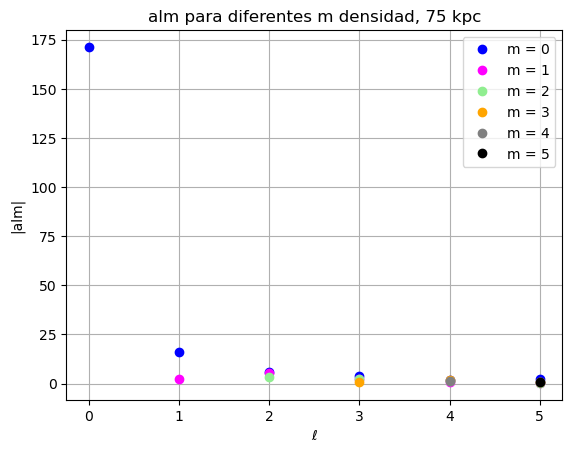

In [163]:
# de los alm hallados en la celda de arriba para densidad 75 kpc
alm_den75 = map2_alm_den75

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_den75[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m densidad, 75 kpc')
plt.grid()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/4146784237.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


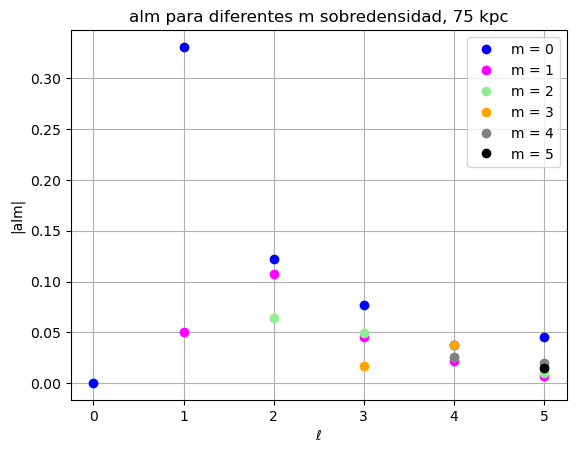

In [164]:
# de los alm hallados en la celda de arriba para la sobredensidad 75 kpc
alm_sobre75 = map2_alm_sobre75

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_sobre75[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m sobredensidad, 75 kpc')
plt.grid()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/654339871.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


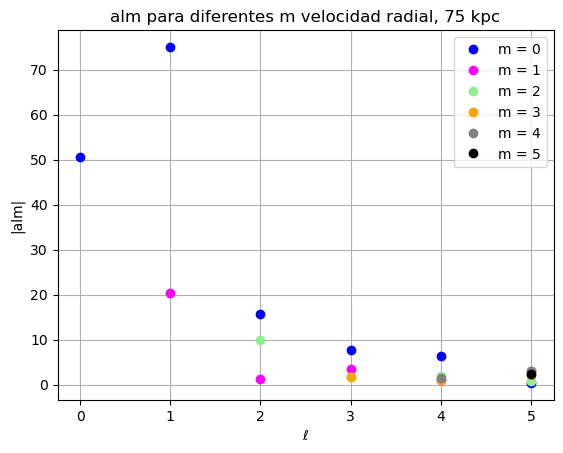

In [165]:
# de los alm hallados en la celda de arriba para la vr75
alm_vr75 = map2_alm_vr75

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_vr75[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m velocidad radial, 75 kpc')
plt.grid()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/3671295041.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


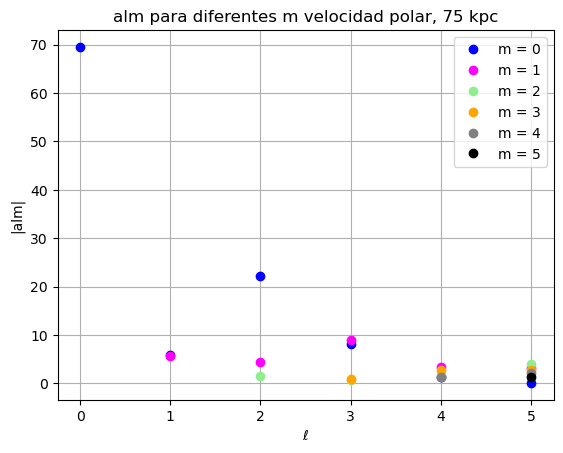

In [166]:
# de los alm hallados en la celda de arriba para vtheta 75
alm_vtheta75 = map2_alm_vtheta75

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_vtheta75[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m velocidad polar, 75 kpc')
plt.grid()
plt.show()

<>:28: SyntaxWarning: invalid escape sequence '\e'
<>:28: SyntaxWarning: invalid escape sequence '\e'
/tmp/ipykernel_103125/128052767.py:28: SyntaxWarning: invalid escape sequence '\e'
  ax.set_xlabel('$\ell$')


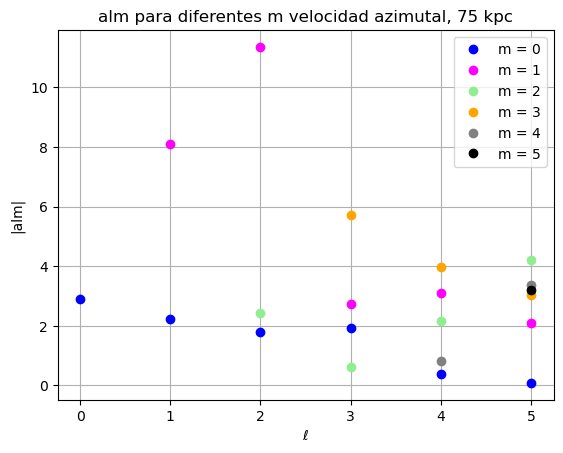

In [167]:
# de los alm hallados en la celda de arriba para la sobredensidad
alm_vphi75 = map2_alm_vphi75

# Obtener los índices de alm
l, m = hp.Alm.getlm(lmax=5)

# Organizar los coeficientes por l y m
indices_ordenados = np.lexsort((m, l))        #ordena primero por m y luego por l. Si un m esta repetido toma el valor del l
l_ordenado = l[indices_ordenados]              #contien los l ordenados
m_ordenado = m[indices_ordenados]             #contiene los m ordenados
alm_ordenado = alm_vphi75[indices_ordenados]      #contiene los valores ordenados de l y m

# color paracada m
colores_m = ['blue', 'magenta', 'lightgreen', 'orange', 'gray', 'black']

# Graficar los coeficientes |alm| vs. l para diferentes m
fig, ax = plt.subplots()


for i, m_val in enumerate(np.unique(m_ordenado)):    #unique porque no puede haber valores repetidos de m
    # Seleccionar los índices correspondientes a un valor específico de m
    #(índices que colocarían los elementos en orden lexicográfico)
    indices_m = np.where(m_ordenado == m_val)

    # Graficar |alm| vs. l para el valor específico de m
    ax.plot(l_ordenado[indices_m], np.abs(alm_ordenado[indices_m]), marker='o', linestyle='', label=f'm = {m_val}', color=colores_m[i])

ax.set_xlabel('$\ell$')
ax.set_ylabel('|alm|')
ax.legend()
plt.title('alm para diferentes m velocidad azimutal, 75 kpc')
plt.grid()
plt.show()

#Cálculos para una shell de 5 kpc centrada en un radio de 100 kpc

In [168]:
radio100_interno_shell = 97.5    # kpc
radio100_externo_shell = 102.5     # kpc


# con el nuevo dataframe estrellas_shell100


estrellas_shell100 = mc[(mc['R'] >= radio100_interno_shell)  & (mc['R'] <= radio100_externo_shell)]

estrellas_shell100


,x,y,z,vx,vy,vz,R,theta,phi,phi2,cotheta,vr2,vtheta2,vphi2
10,31.904644,82.466843,45.244038,115.615623,-142.666092,-78.541245,99.326277,0.472944,1.201653,68.849620,1.097852,-117.089557,28.313850,-159.303718
22,-25.273998,78.493515,54.367474,-35.502800,14.330942,-9.099796,98.771601,0.582887,1.882302,107.847954,0.987910,15.464473,21.095323,29.401844
56,-4.674172,35.479122,94.778435,-67.256638,101.034996,-143.546967,101.309268,1.209773,1.701786,97.505171,0.361024,-95.807175,152.635960,53.483702
192,29.085876,92.773972,-31.267681,-148.099319,48.665298,-44.124615,102.130632,-0.311150,1.266989,72.593097,1.881947,15.538422,41.353161,155.875511
193,-16.705320,-72.439819,68.636650,98.680367,-3.578453,50.305954,101.180951,0.745522,4.485742,-102.985935,0.825274,20.394822,-49.638401,96.960762
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
999820,66.879997,1.086803,72.776932,41.995247,-108.758080,-34.273777,98.846330,0.827532,0.016249,0.930977,0.743265,1.983918,52.807333,-109.426058
999871,-69.040215,25.227917,-69.003578,-42.527020,-284.869934,31.825863,100.819109,-0.753821,2.791257,159.927241,2.324617,-63.943223,16.375138,282.162066
999940,-51.818874,84.830139,7.431798,-181.503372,-194.305435,60.549301,99.682395,0.074624,2.119159,121.418861,1.496172,-66.487834,-65.689104,256.180803
999963,15.020488,81.644043,-57.100761,90.075722,92.588043,-57.195049,100.756448,-0.602520,1.388856,79.575560,2.173317,120.866948,-13.718426,-71.836208


### Mapas de densidad y sobredensidad en 100 kpc

In [169]:
#phi y theta para radio de 100 kpc
phi = estrellas_shell100['phi'].values
theta = estrellas_shell100['cotheta'].values

mapa_hpx100 = cat_to_hpx(theta,phi,   nside, radec=False)      #lon = l, lat = b en grados

#sobredensidad cat_to

sobredensidad_cat100 = (mapa_hpx100 - np.mean(mapa_hpx100))/(np.mean(mapa_hpx100))

La desviación estándar del mapa de densidad, 100 kpc: 7.892723417173293
La desviación estándar del mapa sobredensidad, 75 kpc : 0.22564909296761673


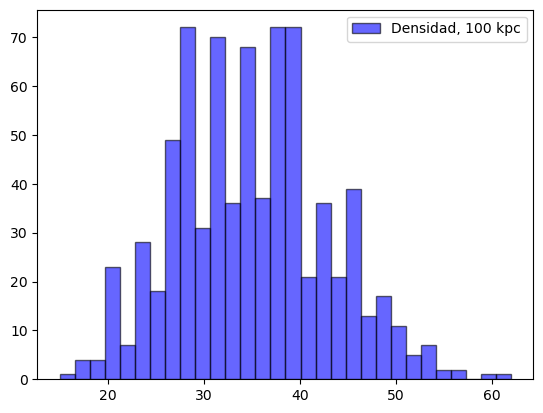

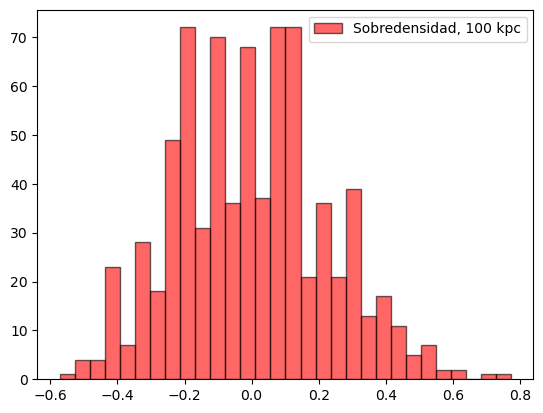

In [170]:
#dispersion densidad y sobre
disp_den100 = np.std(mapa_hpx100)
disp_sobre100 = np.std(sobredensidad_cat100)
print("La desviación estándar del mapa de densidad, 100 kpc:", disp_den100)
print("La desviación estándar del mapa sobredensidad, 75 kpc :", disp_sobre100)

plt.hist(mapa_hpx100, bins=30, color='blue',alpha= 0.6, edgecolor='black', label='Densidad, 100 kpc')
plt.legend()
plt.show()
plt.hist(sobredensidad_cat100, bins=30, color='red',alpha= 0.6, edgecolor='black', label='Sobredensidad, 100 kpc')
plt.legend()

In [171]:
ipix_estrellas_shell100 = hp.ang2pix(nside, theta, phi, lonlat=False)

len(ipix_estrellas_shell100)

26863

### Velocidades

In [172]:
vr_shell100 = estrellas_shell100['vr2'].values
vtheta_shell100 = estrellas_shell100['vtheta2'].values
vphi_shell100 = estrellas_shell100['vphi2'].values

# para cada componente:
mapa_vr_promedio100 = np.zeros(len(mapa_hpx100))
mapa_vtheta_promedio100 = np.zeros(len(mapa_hpx100))
mapa_vphi_promedio100 = np.zeros(len(mapa_hpx100))

# Para cada pixel en el mapa
for i, ipix in enumerate(ipix_estrellas_shell100):
    # Sumar la velocidad promedio de esa componente al pixel correspondiente en el mapa
    # # estos mapas no son la vrelocidad promedio aún, son simplemente la suma de las velocidad de cada estrellas por pixel
    mapa_vr_promedio100[ipix] += vr_shell100[i]
    mapa_vtheta_promedio100[ipix] += vtheta_shell100[i]
    mapa_vphi_promedio100[ipix] += vphi_shell100[i]

# Calcular el promedio dividiendo por el número de estrellas en cada pixel (densidad) OJO


# mapas promedios de vr, vtheta, vphi100
g= mapa_vr_promedio100/mapa_hpx100
h= mapa_vtheta_promedio100/mapa_hpx100
i = mapa_vphi_promedio100/mapa_hpx100


print("Mapa velocidad radial promedio, 100 kpc:", g)
print("Mapa velocidad polar promedio, 100 kpc:", h)
print("Mapa velocidad azimutal promedio, 100 kps:", i)

Mapa velocidad radial promedio, 100 kpc: [ 2.34420917e+01  1.68406870e+01  4.20319351e+01  3.70583982e+01
  3.79769250e+01  8.06459074e+00  3.17010411e+01  2.78032602e+01
  3.38727973e+01  2.86062251e+01  1.94174702e+01  2.22928108e+01
  3.99289952e+01  5.32164195e+01  4.34208931e+01  3.84243909e+01
  3.06048028e+01  5.40843155e+01  5.24451572e+01  2.54436412e+01
  1.95754605e+01  2.96516497e+01  3.80499336e+01  2.00916137e+01
  1.79104053e+01  3.52054082e+01  8.71336505e+00  4.49713404e+01
  2.24560133e+01  5.37299423e+01  5.46700525e+01  3.29280349e+01
  3.04979747e+01  1.08697375e+01  2.66517696e+01  2.80336359e+01
 -3.10419436e-01  5.23225862e+01  4.61026446e+01  3.97892196e+01
  2.93749344e+01  3.43688118e+01  3.05819212e+01  1.95936356e+01
  1.93851583e+01  4.93717741e+01  1.91411083e+01  2.24653992e+01
  2.57106055e+01  3.58863740e+01  2.87477870e+01  8.95870471e+00
  3.16266305e+01  4.48914275e+01  3.14424067e+01  3.80095717e+01
  2.89004933e+01 -7.61142912e+00  2.53877072e+01 

In [173]:

print(np.isnan(g).sum())       # cantidad de valores nan
g[np.isnan(g)] = 0             # se reemplazo los nan por 0
print(np.isnan(g).sum())       # cantidad de nan luego de la modificacion

print(np.isnan(h).sum())
h[np.isnan(h)] = 0
print(np.isnan(h).sum())

print(np.isnan(i).sum())
i[np.isnan(i)] = 0
print(np.isnan(i).sum())


print("Mapa promedio de velocidad radial promedio:", g.mean(), vr_shell.mean())
print("Mapa promedio de velocidad polar promedio:", h.mean(), vtheta_shell.mean())
print("Mapa promedio de velocidad azimutal promedio:", i.mean(), vphi_shell.mean())

0
0
0
0
0
0
Mapa promedio de velocidad radial promedio: -14.951389309911631 -7.171873430020082
Mapa promedio de velocidad polar promedio: -23.766992217810934 -13.858173349418697
Mapa promedio de velocidad azimutal promedio: -0.6888305313634522 -0.23050612314865127


La desviación estándar de velocidad radia promedio, 100 kpc: 32.556554474717466
La desviación estándar de velocidad polar promedio, 100 kpc: 20.44794802059778
La desviación estándar de velocidad azimutal promedio, 100 kpc: 20.728550553678463


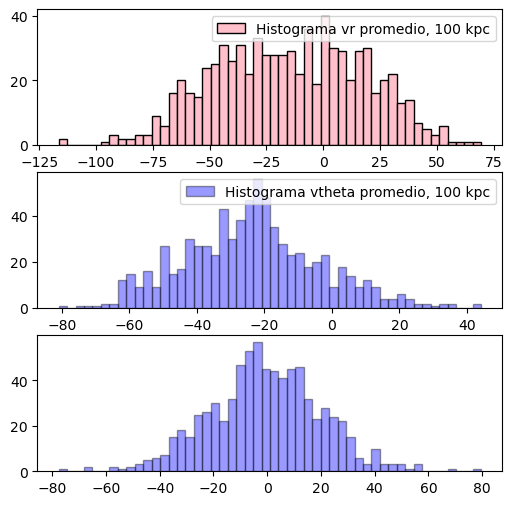

In [174]:
#calculo de los histogramas
histo_vr_prom100, bordes_bins = np.histogram(g, bins=50)
histo_vtheta_prom100, bordes_bins = np.histogram(h , bins=50)
histo_vphi_prom100, bordes_bins = np.histogram(i , bins=50)

# dispersion velocidades
disp_vr_prom100 = np.std(g)
# vthet
disp_vtheta_prom100 = np.std(h )
# vphi
disp_vphi_prom100 = np.std(i )

# print la desviación estandar vr
print("La desviación estándar de velocidad radia promedio, 100 kpc:", disp_vr_prom100)
# print la desviación vtheta
print("La desviación estándar de velocidad polar promedio, 100 kpc:", disp_vtheta_prom100)
# vphi
print("La desviación estándar de velocidad azimutal promedio, 100 kpc:", disp_vphi_prom100)

#histogramas
fig,ax = plt.subplots(3, figsize=(6,6))
ax[0].hist(g , bins=50, color='pink', edgecolor='black', label='Histograma vr promedio, 100 kpc')
ax[0].legend()

ax[1].hist(h , bins=50,color='blue', alpha=0.4, edgecolor='black', label='Histograma vtheta promedio, 100 kpc')
ax[1].legend()
ax[2].hist( i, bins=50,color='blue', alpha=0.4, edgecolor='black', label='Histograma vphi promedio, 100 kpc')
plt.show()

[]

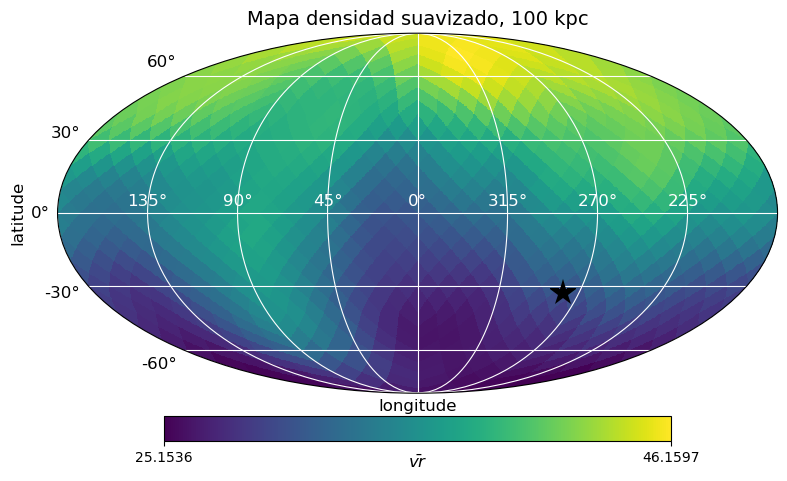

In [175]:
# densidad 100 kpc

# cls2map vr suavizado


mapa_hpx100_smooth = hp.sphtfunc.smoothing(mapa_hpx100, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    mapa_hpx100_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\bar{vr}$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa densidad suavizado, 100 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

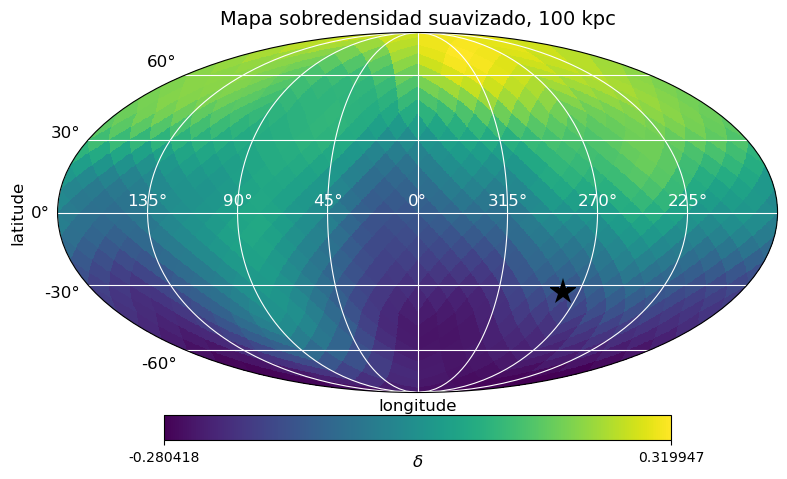

In [176]:
# sobredensidad suavizado 100 kpx


sobre100_smooth = hp.sphtfunc.smoothing(sobredensidad_cat100, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    sobre100_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"$\delta$",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa sobredensidad suavizado, 100 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    #min=-40,
    #max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

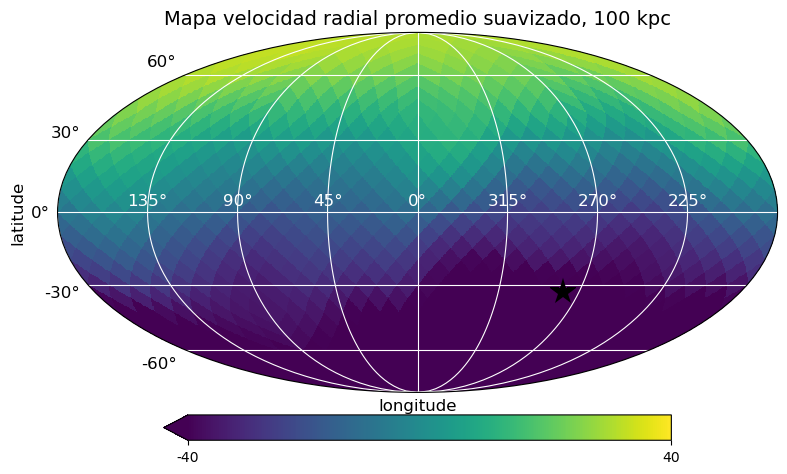

In [177]:
# vr 100 kpc suavizado

vr100_smooth = hp.sphtfunc.smoothing(g, sigma=np.radians(fwhm2sigma(30))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    vr100_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa velocidad radial promedio suavizado, 100 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-40,
    max=40,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

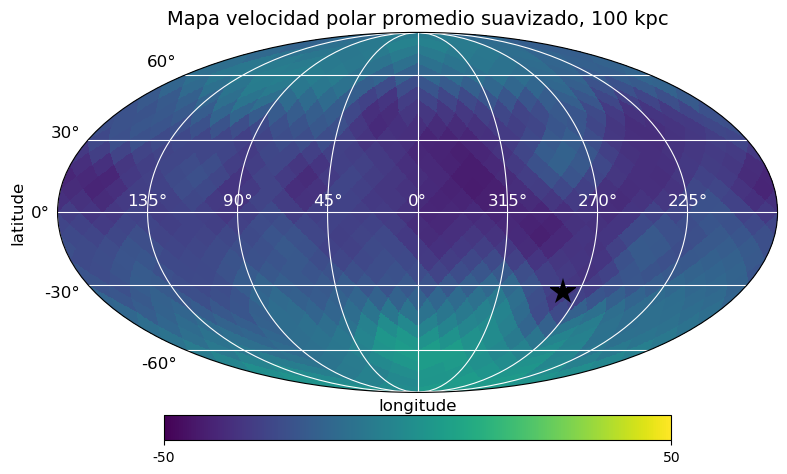

In [178]:
# vpolar 100 kpc suavizado

vtheta100_smooth = hp.sphtfunc.smoothing(h, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    vtheta100_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa velocidad polar promedio suavizado, 100 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    rot=[90,0],
    min=-50,
    max=50,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

[]

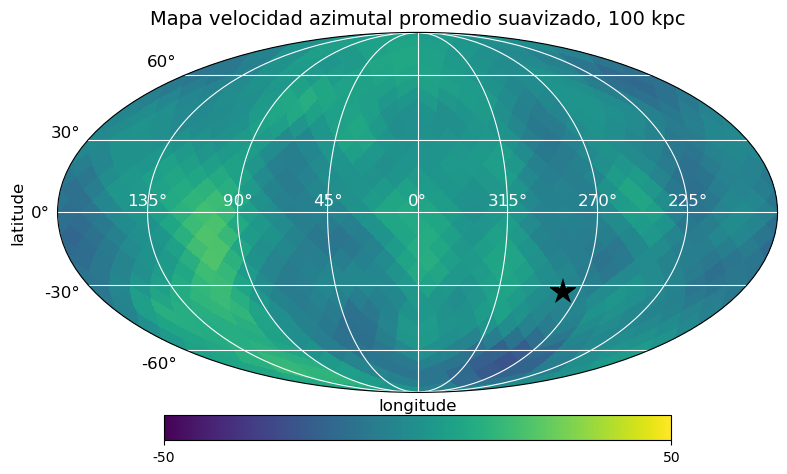

In [179]:
# vphi 100 kpc suavizado

vphi100_smooth = hp.sphtfunc.smoothing(i, sigma=np.radians(fwhm2sigma(20))) # correspond to 30 deg

fig=plt.figure(figsize=(9,5))
ax = fig.add_subplot()
hp.projview(
    vphi100_smooth,
    coord=["G"],
    fig=fig,
    graticule=True,
    graticule_labels=True,
    unit=r"",
    xlabel="longitude",
    ylabel="latitude",
    longitude_grid_spacing=45,
    cb_orientation="horizontal",
   title='Mapa velocidad azimutal promedio suavizado, 100 kpc',
    #cmap="turbo" ,
   xtick_label_color='white',
    ytick_label_color='black',
    graticule_color='white',
    min=-50,
    max=50,
    projection_type="mollweide",flip='astro',zorder=1,hold=True)
hp.newprojplot(np.deg2rad(90-(-33)), np.deg2rad(279-360.0),  marker=r"*", color="k", markersize=20,markeredgewidth=0.01)

plt.plot()

## Cálculo de los Cls para los mapas de densidad, sobredensidad y velocidades, en un radio de 100 kpc, con ```anafast```

In [180]:
#densidad
cls_den100 = hp.anafast(mapa_hpx100, lmax=5)
#sobredensidad
cls_sobre100 = hp.anafast(sobredensidad_cat100, lmax=5)

#velocidad radial
cls_vr100 = hp.anafast(g, lmax=5)
#velocidad polar
cls_vtheta100 = hp.anafast(h, lmax=5)
#velocidad azimutal
cls_vphi100 = hp.anafast(i, lmax=5)

print("Cls para la densidad, 100 kpc:", cls_den100)
print("Cls para la sobredensidad, 100 kpc:", cls_sobre100)
print("Cls velocidad radial promedio, 100 kpc:" , cls_vr100)
print("Cls velocidad polar promedio, 100 kpc:",cls_vtheta100)
print("Cls velocidad azimutal promedio, 100 kpc:",cls_vphi100)

Cls para la densidad, 100 kpc: [1.53746709e+04 1.08693696e+02 9.45820275e+00 2.09320822e+00
 3.00230871e-01 1.00002554e+00]
Cls para la sobredensidad, 100 kpc: [1.46629831e-09 8.88418867e-02 7.73075742e-03 1.71090481e-03
 2.45396717e-04 8.17380941e-04]
Cls velocidad radial promedio, 100 kpc: [2808.92554672 3049.80540685   34.25653794   12.1942672     5.70064018
    5.02418149]
Cls velocidad polar promedio, 100 kpc: [7.08825786e+03 7.29288211e+01 2.25586707e+02 1.60277093e+01
 1.01349300e+01 3.94953560e+00]
Cls velocidad azimutal promedio, 100 kpc: [ 5.96115268 38.18345188 30.03948376 34.99382714 16.69277792  9.31379581]


<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\e'
<>:48: SyntaxWarning: invalid escape sequence '\p'
<>:13: SyntaxWarning: invalid escape sequence '\e'
<>:15: SyntaxWarning: invalid escape sequence '\e'
<>:19: SyntaxWarning: invalid escape sequence '\e'
<>:29: SyntaxWarning: invalid escape sequence '\e'
<>:30: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\e'
<>:45: SyntaxWarning: invalid escape sequence '\p'
<>:46: SyntaxWarning: invalid e

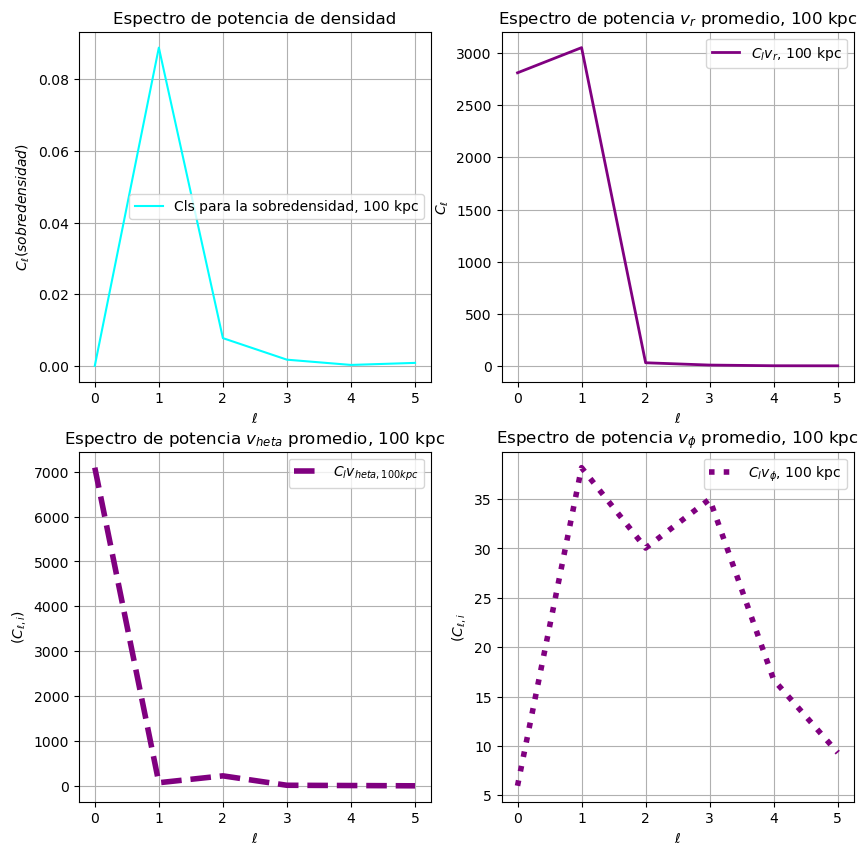

In [181]:
# Espectros

elle = np.arange(len(cls_den))

# como lo usan en el articulo con 2* elle + 1 * cl
# como esta en el tuturial de healpy es elle * (elle + 1) * cl_densidad
#lmax por default: 3*nside-1

fig, ax = plt.subplots(2,2, figsize = (10,10))

############### Cl mapa de densidad
#ax[0,0].plot(elle, cls_hpx_sm, linestyle=None, marker='o', color='purple', lw=2, label='$C_l densidad$, $D = 50$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
#ax[0,0].set_ylim(0,50)
ax[0,0].set_ylabel("$(C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia de densidad')
ax[0,0].plot(elle, cls_sobre100, color='cyan', label='Cls para la sobredensidad, 100 kpc')
#ax[0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$ C_{\ell} (sobredensidad )$")
ax[0,0].legend()
#ax[1].set_ylim(0, 15)
ax[0,0].legend()
ax[0,0].grid()

#plt.plot(elle, elle * (elle + 1) * cl_densidad, color='magenta', lw=2, label='espectro de potencia $D = 50$ kpc')

############### Cl velocidad radial
ax[0,1].plot(elle, cls_vr100 , color='purple', lw=2, label='$C_l v_r$, 100 kpc')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$ C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio, 100 kpc')
ax[0,1].legend()
ax[0,1].grid()

############### Cl velocidad polar

ax[1,0].plot(elle,   cls_vtheta100,   '--',color='purple', lw=4,  label='$C_l v_{\theta, 100 kpc}$')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio, 100 kpc')
ax[1,0].legend()
ax[1,0].grid()

############### Cl velocidad azimutal
ax[1,1].plot(elle,  cls_vphi100, linestyle='dotted', color='purple', lw=4, label='$C_l v_{\phi}$, 100 kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio, 100 kpc')
ax[1,1].legend()
ax[1,1].grid()

# Comparación de todos los espectros de potencia $Cls$ para la densidad, sobredensidad, velocidadaes radial, polar y azimutal, para una shell de 5 kpc, centrada en 50, 75 y 100 kpc

<>:6: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:16: SyntaxWarning: invalid escape sequence '\e'
<>:17: SyntaxWarning: invalid escape sequence '\e'
<>:26: SyntaxWarning: invalid escape sequence '\e'
<>:27: SyntaxWarning: invalid escape sequence '\e'
<>:38: SyntaxWarning: invalid escape sequence '\e'
<>:39: SyntaxWarning: invalid escape sequence '\$'
<>:46: SyntaxWarning: invalid escape sequence '\e'
<>:47: SyntaxWarning: invalid escape sequence '\$'
<>:54: SyntaxWarning: invalid escape sequence '\e'
<>:55: SyntaxWarning: invalid escape sequence '\$'
<>:64: SyntaxWarning: invalid escape sequence '\e'
<>:65: SyntaxWarning: invalid escape sequence '\e'
<>:74: SyntaxWarning: invalid escape sequence '\e'
<>:75: SyntaxWarning: invalid escape sequence '\e'
<>:84: SyntaxWarning: invalid escape sequence '\e'
<>:85: SyntaxWarning: invalid escape sequence '\e'
<>:94: SyntaxWarning: invalid escape sequence '\p'
<>:95: SyntaxWarning: invalid esc

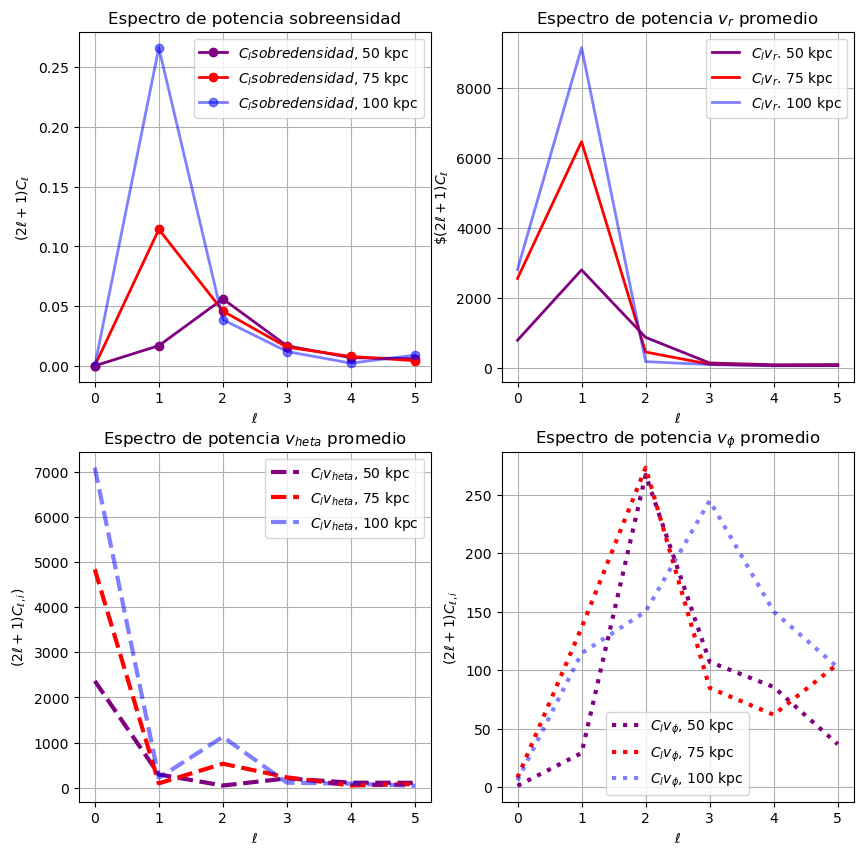

In [185]:

fig, ax = plt.subplots(2,2, figsize = (10,10))

############### Cl mapa de densidad 50 kpc
#ax[0,0].plot(elle, cls_hpx, linestyle=None, marker='o', color='purple', lw=2, label='$C_l densidad$, $D = 50$ kpc')
ax[0,0].plot((2*elle + 1 ) * cls_sobre, linestyle=None, marker='o', color='purple', lw=2, label='$C_l sobredensidad$, $ 50$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$(2\ell + 1 ) C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia sobredensidad')
#ax[0,0].set_ylim(0,5)
ax[0,0].legend()
ax[0,0].grid()


############### Cl mapa de densidad  75 kpc
ax[0,0].plot((2 *  elle + 1 ) * cls_sobre75, linestyle=None, marker='o', color='red', lw=2, label='$C_l sobredensidad$, $75$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$(2\ell + 1 ) C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia sobredensidad')

ax[0,0].legend()
ax[0,0].grid()
#escala de 0

############### Cl mapa de densidad  100 kpc
ax[0,0].plot((2*elle + 1 ) *cls_sobre100, linestyle=None, marker='o', color='blue', alpha= 0.5, lw=2, label='$C_l sobredensidad$, $100$ kpc')  # (2*elle + 1) * cl_densidad
ax[0,0].set_xlabel("$\ell$")
ax[0,0].set_ylabel("$(2\ell + 1 ) C_{\ell}$")
ax[0,0].title.set_text('Espectro de potencia sobreensidad')

ax[0,0].legend()
ax[0,0].grid()

################################################################################################################


############### Cl velocidad radial 50 kpc
ax[0,1].plot((2*elle + 1 ) * cls_vr, color='purple', lw=2, label='$C_l v_r$. 50 kpc')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$\$(2\ell + 1 ) C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio')
ax[0,1].legend()
ax[0,1].grid()

############### Cl velocidad radial 75 kpc
ax[0,1].plot( (2*elle + 1 ) * cls_vr75, color='red', lw=2, label='$C_l v_r$. 75 kpc')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$\$(2\ell + 1 ) C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio')
ax[0,1].legend()
ax[0,1].grid()

############### Cl velocidad radial  100 kpc
ax[0,1].plot( (2*elle + 1 ) * cls_vr100, color='blue', alpha= 0.5, lw=2, label='$C_l v_r$. 100 kpc')  # (2*elle + 1) * cl_densidad
ax[0,1].set_xlabel("$\ell$")
ax[0,1].set_ylabel("$\$(2\ell + 1 ) C_{\ell}$")
ax[0,1].title.set_text(r'Espectro de potencia $v_r$ promedio')
ax[0,1].legend()
ax[0,1].grid()

##############################################################################################################
############### Cl velocidad polar  50 kpc

ax[1,0].plot( (2*elle + 1 ) * cls_vtheta,   '--',color='purple', lw=3,  label='$C_l v_{\theta}$, 50 kpc')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(2 \ell +1)C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio')
ax[1,0].legend()
ax[1,0].grid()


############### Cl velocidad polar 75 kpc

ax[1,0].plot((2*elle + 1 ) * cls_vtheta75,   '--',color='red', lw=3,  label='$C_l v_{\theta}$, 75 kpc')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(2 \ell +1)C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio')
ax[1,0].legend()
ax[1,0].grid()


############### Cl velocidad polar  100 kpc

ax[1,0].plot( (2*elle + 1 )* cls_vtheta100, '--',color='blue', alpha= 0.5, lw=3,  label='$C_l v_{\theta}$, 100 kpc')  # (2*elle + 1) * cl_densidad
ax[1,0].set_xlabel("$\ell$")
ax[1,0].set_ylabel("$(2 \ell +1)C_{\ell , i}$)")
ax[1,0].title.set_text('Espectro de potencia $v_{\theta}$ promedio')
ax[1,0].legend()
ax[1,0].grid()


#################################################################################################################

############### Cl velocidad azimutal  50 kpc
ax[1,1].plot((2*elle + 1 )*cls_vphi, linestyle='dotted', color='purple', lw=3, label='$C_l v_{\phi}$, 50 kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(2 \ell +1)C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio')
ax[1,1].legend()
ax[1,1].grid()


############### Cl velocidad azimutal  75
ax[1,1].plot( (2*elle + 1 )*cls_vphi75, linestyle='dotted', color='red', lw=3, label='$C_l v_{\phi}$, 75 kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(2 \ell +1)C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio')
ax[1,1].legend()
ax[1,1].grid()

############## Cl velocidad azimutal
ax[1,1].plot((2*elle + 1 )*cls_vphi100, linestyle='dotted', color='blue', alpha= 0.5, lw=3, label='$C_l v_{\phi}$, 100 kpc')  # (2*elle + 1) * cl_densidad
ax[1,1].set_xlabel("$\ell$")
ax[1,1].set_ylabel("$(2 \ell +1)C_{\ell, i}$")
ax[1,1].title.set_text('Espectro de potencia $v_{\phi}$ promedio')
ax[1,1].legend()
ax[1,1].grid()

plt.savefig('cls_5075100-comparacion.png')